In [1]:
# Section 0 — Imports and configuration

from pathlib import Path

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib defaults for notebook plots
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 4)

# Project paths (relative to thesis-project root)
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CAMPUS_BUILDING_DATA_DIR = DATA_DIR / "campus-data"
CAMPUS_DATA_OVERVIEW_FILE = CAMPUS_BUILDING_DATA_DIR / "andmed ulevaade.xlsx"
CAMPUS_BUILDING_CODES_FILE = CAMPUS_BUILDING_DATA_DIR / "hooned koodid.xlsx"
COPERNICUS_ERA5_DATA_DIR = DATA_DIR / "copernicus-era5-taltech"
ENVIRONMENT_PORTAL_DATA_DIR = DATA_DIR / "keskkonnaportaal"
COMBINED_WEATHER_FILE = DATA_DIR / "combined_weather_2022_2025.csv"

CAMPUS_BUILDINGS = [
    "GEO", "ICO", "LIB", "SOC", "STU",
    "U01", "U01U02", "U02", "U02B",
    "U03", "U03B", "U04", "U04B",
    "U05", "U05B", "U06", "U06A",
]
CAMPUS_DATA_YEARS = [2022, 2023, 2024]

# Subsystem-type → standardised heating group
SUBSYSTEM_TYPE_TO_GROUP = {
    "peaarvesti": "total",
    "küte": "space_heating",
    "radiaatorid": "space_heating",
    "ventilatsioon": "vent_heating",
    "ventküte": "vent_heating",
    "õhkküte": "vent_heating",
    "vesi": "dhw",
    "väliküte": "outdoor_heating",
    "jääksoojus": "waste_heat",
}

# Estonian measurement-variable names → English column suffixes
MEASUREMENT_VAR_EN = {
    "näit": "energy_mwh",
    "pealevoolu temperatuur": "supply_temp_c",
    "tagasivoolu temperatuur": "return_temp_c",
    "läbivool": "flow_rate_m3h",
    "vooluhulk": "flow_volume_m3",
    "hetkvõimsus": "power_kw",
}


def count_files(path: Path) -> int:
    """Count all files under a directory (recursively)."""
    total = 0
    for _, _, files in os.walk(path):
        total += len(files)
    return total


print(f"CAMPUS_BUILDING_DATA_DIR: {CAMPUS_BUILDING_DATA_DIR}")
print(f"COPERNICUS_ERA5_DATA_DIR: {COPERNICUS_ERA5_DATA_DIR}")
print(f"ENVIRONMENT_PORTAL_DATA_DIR: {ENVIRONMENT_PORTAL_DATA_DIR}")

CAMPUS_BUILDING_DATA_DIR: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/campus-data
COPERNICUS_ERA5_DATA_DIR: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/copernicus-era5-taltech
ENVIRONMENT_PORTAL_DATA_DIR: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/keskkonnaportaal


# Thesis data pipeline

This notebook builds the **data-loading and cleaning pipeline** for the Masters' thesis.

In this pipeline we will:

- load TalTech campus district-heating data for all available buildings (GEO, U01–U06, etc.);
- load historical weather data from **Copernicus ERA5 + Tallinn–Harku (keskkonnaportaal)** for 2022–2024;
- load building metadata (volumes, areas, construction info) from the Estonian Building Registry export;
- clean and align all time series (duplicates, irregular timestamps, outliers, missing data) following the *Energy Data Science – Cleaning* lecture;
- produce a **model-ready, hourly dataset** for each building, with documented completeness and basic diagnostic plots.

Model training and explainability analysis (ES baselines, LSTM, SHAP/PFI) are done in separate notebooks; this file focuses only on reliable, transparent data preparation.

## 3. Data cleaning philosophy and validation

This notebook follows the **Energy Data Science – Cleaning** lecture. Before we touch any values, we are explicit about our goals and how we will validate the results.

- **Goal of cleaning in this thesis**
  - Produce *continuous hourly* time series for each building that are suitable for short-term forecasting (ARX/ARMAX/LSTM).
  - Remove data that clearly does *not* belong in an operational dataset (sensor glitches, meter resets, structural/unit errors).
  - Preserve genuine behaviour: winter peaks, weekday/weekend patterns, summer baseload, etc.

- **What we clean (lecture categories)**
  - **Duplicates**: repeated timestamps when merging multiple sources.
  - **Irrelevant or structurally wrong rows**: impossible timestamps, wrong units, broken aggregations.
  - **Unwanted outliers**: isolated spikes that cannot be explained by physical behaviour or neighbouring values.
  - **Missing data**: detect mechanisms (MCAR / MAR / MNAR) and then choose conservative filling strategies.

- **Missingness mechanisms (MCAR / MAR / MNAR)**
  - We inspect missing data *visually and statistically* to hypothesise whether gaps look random (MCAR), related to other variables such as weather or time (MAR), or related to the values themselves (MNAR).
  - We cannot prove the mechanism, but we document plausible explanations (e.g. communication outages, sensor saturation in heat waves).

- **Validation checklist for this pipeline**
  - Per‑building missingness diagnostics over time and vs. temperature.
  - Before/after percentiles (p95, p99, p99.9, max) for key energy variables.
  - Before/after **time‑series plots** in three representative windows per building:
    - a window around the largest detected spike,
    - one typical **winter** week,
    - one typical **summer** week.
  - Confirm that cleaning removes pathological spikes and bad readings, **without flattening normal dynamics** or introducing obvious bias.

In [2]:
# Section 1 — Campus dataset overview

print(f"CAMPUS_BUILDING_DATA_DIR contains {count_files(CAMPUS_BUILDING_DATA_DIR)} files")
print(f"COPERNICUS_ERA5_DATA_DIR contains {count_files(COPERNICUS_ERA5_DATA_DIR)} files")
print(f"ENVIRONMENT_PORTAL_DATA_DIR contains {count_files(ENVIRONMENT_PORTAL_DATA_DIR)} files")

# Load overview Excel files into reusable DataFrames
overview_df = pd.read_excel(CAMPUS_DATA_OVERVIEW_FILE)
building_codes_df = pd.read_excel(CAMPUS_BUILDING_CODES_FILE)

# Small convenience previews that we can reuse later
overview_head_df = overview_df.head().copy()
building_codes_head_df = building_codes_df.head().copy()

print("\nOverview file columns (andmed ulevaade.xlsx):")
print(overview_df.columns.tolist())

print("\nBuilding codes head (hooned koodid.xlsx):")
display(building_codes_head_df)

CAMPUS_BUILDING_DATA_DIR contains 655 files
COPERNICUS_ERA5_DATA_DIR contains 97 files
ENVIRONMENT_PORTAL_DATA_DIR contains 1 files

Overview file columns (andmed ulevaade.xlsx):
['Hoone', 'Meedium', 'Mõõtepunkti ID', 'ID convert', 'System', 'building_abv', 'level', 'point_id', 'point_name', 'type', 'algus', 'lõpp', 'unit', 'mõõdetud', 2022, 2023, 2024, 'kommentaarid', 'Unnamed: 18', 'Unnamed: 19']

Building codes head (hooned koodid.xlsx):


,kood,EHR register,Hoone,Unnamed: 3,Unnamed: 4
0,U01,link,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/1
1,U02 (+U02B),link,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/2
2,U03 (+U03B),link,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/3
3,U04,link,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/4
4,U04B,link,õppehoone n 4B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Ehitajate tee 5/8


## 1.1 Building-level data availability

In the TalTech campus overview file each **row is a measurement point**, not a building.  
For the pipeline it is more useful to summarise **how many measurement files exist per building and year**.  
Below we build a compact table (buildings × years) and a simple, thesis-ready heatmap based on that summary.

Measurement-file counts per building and year (from overview Excel):


,2022,2023,2024
Hoone,,,
GEO,9,9,14
ICO,12,12,12
LIB,9,9,9
SOC,12,12,12
STU,1,1,1
U01,12,12,12
U01U02,1,1,1
U02,9,9,9
U02B,7,7,7


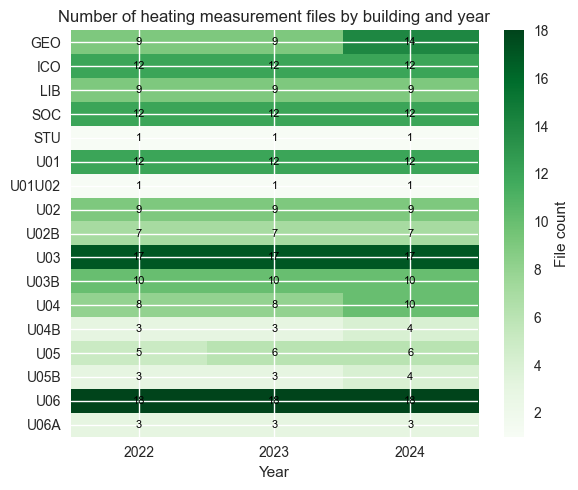

In [3]:
# Summarise number of measurement files per building and year

building_year_counts = (
    overview_df
    .loc[overview_df["Hoone"].isin(CAMPUS_BUILDINGS), ["Hoone", 2022, 2023, 2024]]
    .groupby("Hoone")[[2022, 2023, 2024]]
    .apply(lambda df: df.notna().sum())
    .sort_index()
)

print("Measurement-file counts per building and year (from overview Excel):")
display(building_year_counts)

# For a compact visual, use counts directly in a small heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(building_year_counts.values, aspect="auto", cmap="Greens")

ax.set_yticks(range(len(building_year_counts.index)))
ax.set_yticklabels(building_year_counts.index)
ax.set_xticks(range(len(building_year_counts.columns)))
ax.set_xticklabels(building_year_counts.columns)

ax.set_xlabel("Year")
ax.set_title("Number of heating measurement files by building and year")

for i, building in enumerate(building_year_counts.index):
    for j, year in enumerate(building_year_counts.columns):
        val = building_year_counts.iloc[i, j]
        ax.text(
            j,
            i,
            str(val),
            ha="center",
            va="center",
            color="black",
            fontsize=8,
        )

plt.colorbar(im, ax=ax, label="File count")
plt.tight_layout()
plt.show()

## 1.2 Understanding the measurement structure

Each row in `overview_df` represents **one measurement point** (a single time series from a single heat meter sensor). To use this data correctly — especially to avoid confusing hot-water heating with space heating — we need to understand three dimensions:

1. **Subsystem type** (`type` column) — *what* is being heated  
2. **Measured variable** (`mõõdetud` column) — *what* is being recorded  
3. **Meter hierarchy** (`level` column) — is this the building's **main meter** or a **sub-meter**

### Subsystem types

| Estonian | English | Heating group | Weather-driven? |
|---|---|---|---|
| `peaarvesti` | main meter (whole building) | `total` | aggregates all |
| `küte` | space heating (radiator circuits) | `space_heating` | yes |
| `radiaatorid` | radiators (SOC, U06 naming) | `space_heating` | yes |
| `ventilatsioon` | ventilation AHU coils | `vent_heating` | yes |
| `ventküte` | ventilation heating (U01 naming) | `vent_heating` | yes |
| `õhkküte` | air heating (SOC naming) | `vent_heating` | yes |
| `vesi` | domestic hot water (DHW) | `dhw` | **no** |
| `väliküte` | outdoor / snow-melt heating | `outdoor_heating` | yes |
| `jääksoojus` | waste-heat recovery (U06 only) | `waste_heat` | special |

### Measured variables

| Estonian (`mõõdetud`) | English | Unit | Notes |
|---|---|---|---|
| `näit` | cumulative energy reading | MWh | primary target for modelling |
| `pealevoolu temperatuur` | supply temperature | °C | heat-carrier supply |
| `tagasivoolu temperatuur` | return temperature | °C | heat-carrier return |
| `läbivool` | instantaneous flow rate | m³/h | rare, only some main meters |
| `vooluhulk` | cumulative flow volume | m³ | rare |
| `hetkvõimsus` | instantaneous power | kW | NRG only |

### Why this matters

- **DHW (`vesi`) is weather-independent** — it must be separated when building a weather-driven heat-demand model.  
- The **main meter (`peaarvesti`)** aggregates all subsystems; using it as the target means predicting *total* heat including DHW.  
- For a clean weather-dependent target: sum `space_heating + vent_heating + outdoor_heating` (excluding `dhw` and `waste_heat`).  
- Some buildings share meters across physical structures (see below).

In [4]:
# Apply the mappings from Section 0 to create new columns on overview_df

overview_df["heating_group"] = overview_df["type"].map(SUBSYSTEM_TYPE_TO_GROUP)
overview_df["mõõdetud_en"] = overview_df["mõõdetud"].map(MEASUREMENT_VAR_EN)

# Composite label: uniquely identifies every measurement point
overview_df["label"] = (
    overview_df["Hoone"]
    + "_"
    + overview_df["ID convert"].str.split(".").str[1]
    + "_"
    + overview_df["type"]
    + "_"
    + overview_df["mõõdetud_en"]
)

print(f"Total measurement points: {len(overview_df)}")
print(f"Unique buildings (Hoone):  {overview_df['Hoone'].nunique()}")
print(f"Unique subsystem types:    {overview_df['type'].nunique()}")
print(f"Unique measured variables:  {overview_df['mõõdetud'].nunique()}")
print()
print("Sample labels (first 6):")
for lbl in overview_df["label"].head(6):
    print(f"  {lbl}")

Total measurement points: 163
Unique buildings (Hoone):  18
Unique subsystem types:    9
Unique measured variables:  6

Sample labels (first 6):
  GEO_BHB01_peaarvesti_energy_mwh
  GEO_BHB01_peaarvesti_flow_rate_m3h
  GEO_BHB01_peaarvesti_flow_volume_m3
  GEO_BHB01_peaarvesti_supply_temp_c
  GEO_BHB01_peaarvesti_return_temp_c
  GEO_BHB02_küte_energy_mwh


In [5]:
# Energy (MWh, näit) measurement points per building × heating group

energy_points = overview_df[
    (overview_df["mõõdetud"] == "näit") & (overview_df["unit"] == "MWh")
]

energy_pivot = energy_points.pivot_table(
    index="Hoone",
    columns="heating_group",
    values="label",
    aggfunc="count",
    fill_value=0,
)

# Reorder columns for readability
col_order = [c for c in ["total", "space_heating", "vent_heating", "outdoor_heating", "dhw", "waste_heat"] if c in energy_pivot.columns]
energy_pivot = energy_pivot[col_order]

print("Energy sub-meter counts per building and heating group:")
display(energy_pivot)

Energy sub-meter counts per building and heating group:


heating_group,total,space_heating,vent_heating,outdoor_heating,dhw,waste_heat
Hoone,,,,,,
GEO,1,1,1,0,1,0
ICO,0,2,1,0,1,0
LIB,0,1,1,0,1,0
NRG,1,1,1,0,1,0
SOC,0,1,2,0,1,0
STU,1,0,0,0,0,0
U01,0,1,1,1,1,0
U01U02,1,0,0,0,0,0
U02,0,0,2,0,1,0


### Main meters vs sub-meters

Each building **ideally** has one `peaarvesti` (main meter, `level=main`) that measures **total** district-heating consumption. Below it, several sub-meters (`level=sub`) track individual subsystems.

**Relationship:**  `peaarvesti ≈ küte + ventilatsioon + vesi + väliküte + jääksoojus`

Five buildings **lack a main meter**: ICO, LIB, SOC, U01, U02. For these, total heat must be estimated by summing the available sub-meters.

### Cross-building (shared) meters

Some meters physically serve more than one building. The `building_abv` column reveals which physical building/pair the meter actually belongs to:

| Meter (`ID convert`) | Listed under (`Hoone`) | Actual building(s) (`building_abv`) | What it measures |
|---|---|---|---|
| U01.BHB02 | U01 | **U01U02** | shared space heating for U01+U02 |
| U01.BHB03 | U01 | **U02** | U02 materials-lab ventilation heating |
| U02.BHB02 | U02 | **U02U02B** | shared DHW for U02+U02B |

**U01U02.BHB01** is the main meter for U01 + U02 combined. The pipeline must track these shared meters to avoid double-counting or misattribution.

In [6]:
# Identify main meters vs sub-meters and cross-building meters

main_meters = overview_df[
    (overview_df["level"] == "main")
    & (overview_df["mõõdetud"] == "näit")
    & (overview_df["unit"] == "MWh")
][["Hoone", "ID convert", "type", "level"]]

all_buildings = set(overview_df["Hoone"].unique())
buildings_with_main = set(main_meters["Hoone"].unique())
buildings_without_main = sorted(all_buildings - buildings_with_main)

print("Buildings WITH main meter (peaarvesti):")
display(main_meters.sort_values("Hoone").reset_index(drop=True))

print(f"\nBuildings WITHOUT main meter: {buildings_without_main}")

# Cross-building (shared) meters
cross_building = overview_df[overview_df["Hoone"] != overview_df["building_abv"]]
if len(cross_building) > 0:
    print(f"\nCross-building meters ({len(cross_building)} rows):")
    display(
        cross_building[["Hoone", "building_abv", "ID convert", "type", "mõõdetud", "System"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

Buildings WITH main meter (peaarvesti):


,Hoone,ID convert,type,level
0,GEO,GEO.BHB01,peaarvesti,main
1,NRG,NRG.BHB01,peaarvesti,main
2,STU,STU.BHB01,peaarvesti,main
3,U01U02,U01U02.BHB01,peaarvesti,main
4,U02B,U02B.BHB01,peaarvesti,main
5,U03,U03.BHB01,peaarvesti,main
6,U03B,U03B.BHB01,peaarvesti,main
7,U04,U04.BHB01,peaarvesti,main
8,U04B,U04B.BHB01,peaarvesti,main
9,U05,U05.BHB01,peaarvesti,main



Buildings WITHOUT main meter: ['ICO', 'LIB', 'SOC', 'U01', 'U02']

Cross-building meters (9 rows):


,Hoone,building_abv,ID convert,type,mõõdetud,System
0,U01,U01U02,U01.BHB02,küte,näit,U01U02 - küte
1,U01,U01U02,U01.BHB02,küte,pealevoolu temperatuur,U01U02 - küte
2,U01,U01U02,U01.BHB02,küte,tagasivoolu temperatuur,U01U02 - küte
3,U01,U02,U01.BHB03,ventküte,näit,U02 - SV6 Mat_uuringute labori ventküte
4,U01,U02,U01.BHB03,ventküte,pealevoolu temperatuur,U02 - SV6 Mat_uuringute labori ventküte
5,U01,U02,U01.BHB03,ventküte,tagasivoolu temperatuur,U02 - SV6 Mat_uuringute labori ventküte
6,U02,U02U02B,U02.BHB02,vesi,näit,U02U02B - soe vesi
7,U02,U02U02B,U02.BHB02,vesi,pealevoolu temperatuur,U02U02B - soe vesi
8,U02,U02U02B,U02.BHB02,vesi,tagasivoolu temperatuur,U02U02B - soe vesi


In [7]:
# Date ranges per building (from overview metadata)

date_ranges = (
    overview_df
    .groupby("Hoone")
    .agg(
        earliest_start=("algus", "min"),
        latest_end=("lõpp", "max"),
        n_points=("label", "count"),
    )
    .sort_index()
)

print("Data availability per building (from overview metadata):")
display(date_ranges)

Data availability per building (from overview metadata):


,earliest_start,latest_end,n_points
Hoone,,,
GEO,2022-05-23,2024-12-31,14
ICO,2022-05-20,2024-12-31,12
LIB,2022-05-20,2024-12-31,9
NRG,2022-01-01,2024-12-31,14
SOC,2022-05-20,2024-12-31,12
STU,2022-01-01,2024-12-31,1
U01,2022-05-20,2024-12-31,12
U01U02,2022-01-01,2024-01-10,1
U02,2022-05-20,2024-12-31,9


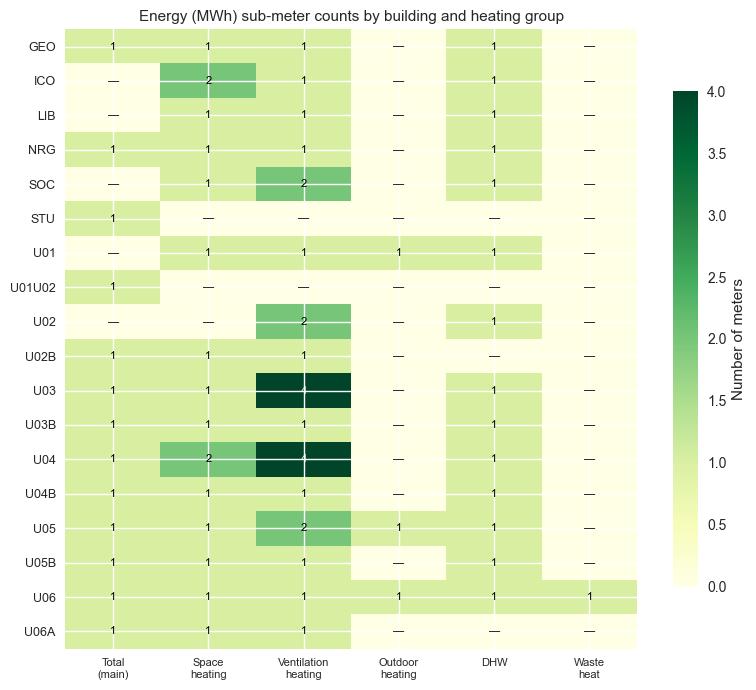

In [8]:
# Heatmap: heating-group breakdown per building (energy meters only)

group_order = ["total", "space_heating", "vent_heating", "outdoor_heating", "dhw", "waste_heat"]
group_labels = ["Total\n(main)", "Space\nheating", "Ventilation\nheating", "Outdoor\nheating", "DHW", "Waste\nheat"]

# Build matrix
buildings_sorted = sorted(energy_pivot.index)
matrix = np.zeros((len(buildings_sorted), len(group_order)), dtype=int)
for i, bldg in enumerate(buildings_sorted):
    for j, grp in enumerate(group_order):
        if grp in energy_pivot.columns and bldg in energy_pivot.index:
            matrix[i, j] = energy_pivot.loc[bldg, grp]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matrix, aspect="auto", cmap="YlGn", vmin=0)

ax.set_yticks(range(len(buildings_sorted)))
ax.set_yticklabels(buildings_sorted, fontsize=9)
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_labels, fontsize=8)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix[i, j]
        ax.text(j, i, str(val) if val > 0 else "—",
                ha="center", va="center", fontsize=8,
                color="white" if val >= 3 else "black")

ax.set_title("Energy (MWh) sub-meter counts by building and heating group", fontsize=11)
plt.colorbar(im, ax=ax, label="Number of meters", shrink=0.8)
plt.tight_layout()
plt.show()

### 1.3 Loading manifest

The `overview_df` with its new `label` and `heating_group` columns now serves as the **loading manifest** for Section 2.  
Each row with a non-null filename in the 2022/2023/2024 columns tells us exactly which CSV to load, what building it belongs to, what subsystem type it is, and how to label the resulting column.

Below is the complete set of **energy** measurement points (cumulative MWh readings) that will form the core of our dataset.

In [9]:
# Full manifest of measurement points (for loading in Section 2)

manifest_cols = ["Hoone", "ID convert", "type", "heating_group", "mõõdetud", "mõõdetud_en",
                 "unit", "level", "label", 2022, 2023, 2024]

manifest_df = overview_df[manifest_cols].sort_values(
    ["Hoone", "level", "type", "mõõdetud"]
).reset_index(drop=True)

print(f"Total measurement points in manifest: {len(manifest_df)}")
print(f"  of which energy (MWh, näit): {len(energy_points)}")
print(f"  of which temperature (°C):   {len(overview_df[overview_df['unit'] == '℃'])}")
print(f"  of which other (flow, power): {len(overview_df[overview_df['unit'].isin(['m3', 'm3/h', 'kW'])])}")

display(manifest_df.head(20))

Total measurement points in manifest: 163
  of which energy (MWh, näit): 73
  of which temperature (°C):   86
  of which other (flow, power): 4


,Hoone,ID convert,type,heating_group,mõõdetud,mõõdetud_en,unit,level,label,2022,2023,2024
0,GEO,GEO.BHB01,peaarvesti,total,läbivool,flow_rate_m3h,m3/h,main,GEO_BHB01_peaarvesti_flow_rate_m3h,NaN,NaN,GEO_BHB01_Läbivool_2024.csv
1,GEO,GEO.BHB01,peaarvesti,total,näit,energy_mwh,MWh,main,GEO_BHB01_peaarvesti_energy_mwh,NaN,NaN,GEO_BHB01_näit_2024.csv
2,GEO,GEO.BHB01,peaarvesti,total,pealevoolu temperatuur,supply_temp_c,℃,main,GEO_BHB01_peaarvesti_supply_temp_c,NaN,NaN,GEO_BHB01_pealevoolu temp_2024.csv
3,GEO,GEO.BHB01,peaarvesti,total,tagasivoolu temperatuur,return_temp_c,℃,main,GEO_BHB01_peaarvesti_return_temp_c,NaN,NaN,GEO_BHB01_tagasivoolu temp_2024.csv
4,GEO,GEO.BHB01,peaarvesti,total,vooluhulk,flow_volume_m3,m3,main,GEO_BHB01_peaarvesti_flow_volume_m3,NaN,NaN,GEO_BHB01_vooluhulk_2024.csv
5,GEO,GEO.BHB02,küte,space_heating,näit,energy_mwh,MWh,sub,GEO_BHB02_küte_energy_mwh,GEO_BHB02_näit_2022.csv,GEO_BHB02_näit_2023.csv,GEO_BHB02_näit_2024.csv
6,GEO,GEO.BHB02,küte,space_heating,pealevoolu temperatuur,supply_temp_c,℃,sub,GEO_BHB02_küte_supply_temp_c,GEO_BHB02_pealevoolu temp_2022.csv,GEO_BHB02_pealevoolu temp_2023.csv,GEO_BHB02_pealevoolu temp_2024.csv
7,GEO,GEO.BHB02,küte,space_heating,tagasivoolu temperatuur,return_temp_c,℃,sub,GEO_BHB02_küte_return_temp_c,GEO_BHB02_tagasivoolu temp_2022.csv,GEO_BHB02_tagasivoolu temp_2023.csv,GEO_BHB02_tagasivoolu temp_2024.csv
8,GEO,GEO.BHB03,ventilatsioon,vent_heating,näit,energy_mwh,MWh,sub,GEO_BHB03_ventilatsioon_energy_mwh,GEO_BHB03_näit_2022.csv,GEO_BHB03_näit_2023.csv,GEO_BHB03_näit_2024.csv
9,GEO,GEO.BHB03,ventilatsioon,vent_heating,pealevoolu temperatuur,supply_temp_c,℃,sub,GEO_BHB03_ventilatsioon_supply_temp_c,GEO_BHB03_pealevoolu temp_2022.csv,GEO_BHB03_pealevoolu temp_2023.csv,GEO_BHB03_pealevoolu temp_2024.csv


## 2. Raw CSV loading for all campus buildings

In this section we:

1. **Demonstrate** loading a single CSV file (U06 example) to show the raw structure.  
2. **Use `manifest_df` as a loading manifest**: for each measurement point and year we read the corresponding CSV, parse timestamps, and build a time-indexed `pandas.Series`.  
3. **Assemble one `DataFrame` per building** by concatenating all Series with their composite `label` column names.

The goal is a transparent, manifest-driven loader: no guessed file paths, no hidden utilities, and a clear mapping from each CSV to a labeled time series.

In [10]:
# 2.1 Example: load one raw CSV for U06

# Pick one cumulative energy point for U06 (prefer main meter if present)
example_row = (
    manifest_df[
        (manifest_df["Hoone"] == "U06")
        & (manifest_df["mõõdetud_en"] == "energy_mwh")
    ]
    .sort_values(["level", "type"])
    .iloc[0]
)

print("Example manifest entry for U06:")
print(example_row[["Hoone", "ID convert", "type", "heating_group", "mõõdetud", "unit", "level", "label"]])

# Choose the first year where a file exists
example_year = None
for year in CAMPUS_DATA_YEARS:
    fname = example_row[year]
    if isinstance(fname, str) and fname.strip():
        example_year = year
        break

print(f"\nUsing year: {example_year}")
example_filename = example_row[example_year]
example_path = CAMPUS_BUILDING_DATA_DIR / example_row["Hoone"] / str(example_year) / example_filename

print(f"Raw CSV path: {example_path}")

example_df = pd.read_csv(example_path)
print("\nRaw CSV head:")
print(example_df.head())

print("\nRaw CSV dtypes:")
print(example_df.dtypes)

# Parse into a simple time-indexed Series (cumulative MWh)
example_series = (
    example_df
    .assign(Time=pd.to_datetime(example_df["Time"], errors="coerce"))
    .set_index("Time")["Value"]
    .dropna()
)

print("\nParsed example series (first 10 values):")
print(example_series.head(10))

Example manifest entry for U06:
Hoone                                        U06
ID convert                             U06.BHB01
type                                  peaarvesti
heating_group                              total
mõõdetud                                    näit
unit                                         MWh
level                                       main
label            U06_BHB01_peaarvesti_energy_mwh
Name: 142, dtype: object

Using year: 2022
Raw CSV path: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/campus-data/U06/2022/U06_BHB01_näit_2022.csv

Raw CSV head:
                                        Point name                 Time  \
0  RAW - TalTech - S - U06.BHB01 - Nait - 65178746  2022/01/01 00:20:00   
1  RAW - TalTech - S - U06.BHB01 - Nait - 65178746  2022/01/01 00:30:00   
2  RAW - TalTech - S - U06.BHB01 - Nait - 65178746  2022/01/01 01:30:00   
3  RAW - TalTech - S - U06.BHB01 - Nait - 65178746  2022/01/01 02:10:00   
4  RAW - TalTech - S

In [11]:
# 2.2 Helper: load all years for a single manifest row into one Series

from typing import Optional


def load_manifest_row_series(row: pd.Series, years: list[int] | None = None) -> Optional[pd.Series]:
    """Load one manifest row (one measurement point) into a single time-indexed Series.

    - Uses `row['Hoone']` as the building folder.
    - Uses the 2022/2023/2024 columns for filenames.
    - Concatenates all years and collapses any duplicate timestamps by keeping the last value.
    """
    if years is None:
        years = CAMPUS_DATA_YEARS

    series_parts: list[pd.Series] = []

    for year in years:
        fname = row.get(year)
        if not isinstance(fname, str) or not fname.strip():
            continue

        path = CAMPUS_BUILDING_DATA_DIR / row["Hoone"] / str(year) / fname
        if not path.exists():
            print(f"[WARN] Missing file for {row['label']} {year}: {path}")
            continue

        df_raw = pd.read_csv(path)
        if "Time" not in df_raw.columns or "Value" not in df_raw.columns:
            print(f"[WARN] Unexpected columns in {path.name}, skipping.")
            continue

        time = pd.to_datetime(df_raw["Time"], errors="coerce")
        values = pd.to_numeric(df_raw["Value"], errors="coerce")

        s = pd.Series(values.values, index=time)
        # Drop rows where either the value is NaN or the timestamp is NaT
        s = s[s.index.notna()].dropna()
        series_parts.append(s)

    if not series_parts:
        return None

    combined = pd.concat(series_parts).sort_index()
    combined = combined.groupby(level=0).last()
    combined.name = row["label"]
    return combined

In [12]:
# 2.3 Load all manifest entries into per-building DataFrames

building_series: dict[str, list[pd.Series]] = {b: [] for b in CAMPUS_BUILDINGS}

for _, row in manifest_df.iterrows():
    building = row["Hoone"]
    if building not in CAMPUS_BUILDINGS:
        continue

    s = load_manifest_row_series(row)
    if s is None or s.empty:
        continue

    building_series[building].append(s)


building_dfs: dict[str, pd.DataFrame] = {}

for building, series_list in building_series.items():
    if not series_list:
        continue

    df_building = pd.concat(series_list, axis=1)
    df_building = df_building.sort_index()
    building_dfs[building] = df_building

print(f"Total buildings with data: {len(building_dfs)}\n")

for building, df in sorted(building_dfs.items()):
    print(f"{building}: {df.shape[1]:>2} columns, {df.shape[0]:>6} unique timestamps")

[WARN] Missing file for SOC_BHB02_radiaatorid_supply_temp_c 2022: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/campus-data/SOC/2022/SOC_BHB02_pealevoolu temp_202.csv
Total buildings with data: 17

GEO: 14 columns, 109987 unique timestamps
ICO: 12 columns, 132175 unique timestamps
LIB:  9 columns,  38832 unique timestamps
SOC: 12 columns,  38833 unique timestamps
STU:  1 columns,  50140 unique timestamps
U01: 12 columns,  40154 unique timestamps
U01U02:  1 columns,  24492 unique timestamps
U02:  9 columns,  30392 unique timestamps
U02B:  7 columns,  38072 unique timestamps
U03: 17 columns,  38073 unique timestamps
U03B: 10 columns,  37382 unique timestamps
U04: 10 columns,  38073 unique timestamps
U04B:  4 columns,  37670 unique timestamps
U05:  6 columns,  37806 unique timestamps
U05B:  4 columns,  37404 unique timestamps
U06: 18 columns,  37670 unique timestamps
U06A:  3 columns,  37340 unique timestamps


### 2.4 Why the raw DataFrames appear sparse

Each building's DataFrame is assembled by **outer-joining** every measurement series on the timestamp index. Since different sensors record at **different timestamps** (and even start/end on different dates), the union of all timestamps creates a matrix where most cells are NaN — this is expected and correct.

**No data is lost.** Each column individually retains all its original data points. The NaN entries simply mean "this sensor did not report at this particular timestamp". This will be resolved later when we resample everything to a common hourly grid (Section 3).

In [13]:
# 2.4 Verification: per-column data-point counts vs raw CSV row counts
# This proves that no data is lost during loading.

def verify_building(building: str, df: pd.DataFrame) -> pd.DataFrame:
    """Compare loaded non-null counts against expected raw CSV row counts."""
    rows = []
    for col in df.columns:
        loaded_count = df[col].notna().sum()
        first_ts = df[col].dropna().index.min()
        last_ts = df[col].dropna().index.max()
        rows.append({
            "column": col,
            "loaded_points": loaded_count,
            "first_timestamp": first_ts,
            "last_timestamp": last_ts,
        })
    return pd.DataFrame(rows)


# Verify U06 as our reference building
if "U06" in building_dfs:
    u06_verify = verify_building("U06", building_dfs["U06"])
    print("U06 — loaded data points per column (non-null values):\n")
    display(u06_verify)

    total_loaded = u06_verify["loaded_points"].sum()
    total_cells = building_dfs["U06"].size
    sparsity = 1 - (total_loaded / total_cells)
    print(f"\nTotal loaded values: {total_loaded:,}")
    print(f"Total cells in DataFrame: {total_cells:,}")
    print(f"Sparsity (expected, due to timestamp misalignment): {sparsity:.1%}")

U06 — loaded data points per column (non-null values):



,column,loaded_points,first_timestamp,last_timestamp
0,U06_BHB01_peaarvesti_energy_mwh,24248,2022-01-01 00:20:00,2024-01-15 10:15:00
1,U06_BHB01_peaarvesti_supply_temp_c,19513,2022-03-30 12:50:00,2024-01-15 10:15:00
2,U06_BHB01_peaarvesti_return_temp_c,19567,2022-03-30 12:50:00,2024-01-15 10:15:00
3,U06_BHB02_jääksoojus_energy_mwh,35284,2022-02-14 11:20:00,2024-12-30 18:00:00
4,U06_BHB02_jääksoojus_supply_temp_c,32968,2022-03-30 12:50:00,2024-12-30 18:00:00
5,U06_BHB02_jääksoojus_return_temp_c,33024,2022-03-30 12:50:00,2024-12-30 18:00:00
6,U06_BHB03_radiaatorid_energy_mwh,35284,2022-02-14 11:20:00,2024-12-30 18:00:00
7,U06_BHB03_radiaatorid_supply_temp_c,33038,2022-03-30 12:50:00,2024-12-30 18:00:00
8,U06_BHB03_radiaatorid_return_temp_c,33016,2022-03-30 12:50:00,2024-12-30 18:00:00
9,U06_BHB04_ventilatsioon_energy_mwh,35284,2022-02-14 11:20:00,2024-12-30 18:00:00



Total loaded values: 564,029
Total cells in DataFrame: 678,060
Sparsity (expected, due to timestamp misalignment): 16.8%


In [14]:
# 2.4b Cross-validation: independently count raw CSV rows and duplicate timestamps for U06

if "U06" in building_dfs:
    u06_rows = manifest_df[manifest_df["Hoone"] == "U06"]

    print("U06 — raw rows vs loaded (non-null) values per column:\n")
    print(f"  {'column':<50s}  {'raw':>6}  {'dupes':>5}  {'loaded':>6}  {'status'}")
    print(f"  {'-'*50}  {'-'*6}  {'-'*5}  {'-'*6}  {'-'*6}")

    all_ok = True
    for _, row in u06_rows.iterrows():
        label = row["label"]
        if label not in building_dfs["U06"].columns:
            continue

        raw_total = 0
        all_timestamps: list[pd.Series] = []

        for year in CAMPUS_DATA_YEARS:
            fname = row.get(year)
            if not isinstance(fname, str) or not fname.strip():
                continue
            path = CAMPUS_BUILDING_DATA_DIR / row["Hoone"] / str(year) / fname
            if path.exists():
                df_check = pd.read_csv(path)
                raw_total += len(df_check)
                all_timestamps.append(pd.to_datetime(df_check["Time"], errors="coerce"))

        # Count duplicate timestamps across all year-files
        if all_timestamps:
            combined_ts = pd.concat(all_timestamps, ignore_index=True)
            n_dupes = int(len(combined_ts) - combined_ts.nunique())
        else:
            n_dupes = 0

        loaded = int(building_dfs["U06"][label].notna().sum())
        expected = raw_total - n_dupes
        status = "OK" if loaded == expected else "MISMATCH"
        if status != "OK":
            all_ok = False
        print(f"  {label:<50s}  {raw_total:>6}  {n_dupes:>5}  {loaded:>6}  {status}")

    print()
    if all_ok:
        print("All columns: loaded == raw − duplicates. No data lost.")
        print("(Duplicates are exact-duplicate timestamps from meter logging artifacts and DST clock changes.)")
    else:
        print("WARNING: some columns have unexplained mismatches — investigate further.")

U06 — raw rows vs loaded (non-null) values per column:

  column                                                 raw  dupes  loaded  status
  --------------------------------------------------  ------  -----  ------  ------
  U06_BHB01_peaarvesti_energy_mwh                      24253      5   24248  OK
  U06_BHB01_peaarvesti_supply_temp_c                   19518      5   19513  OK
  U06_BHB01_peaarvesti_return_temp_c                   19572      5   19567  OK
  U06_BHB02_jääksoojus_energy_mwh                      35326     42   35284  OK
  U06_BHB02_jääksoojus_supply_temp_c                   33008     40   32968  OK
  U06_BHB02_jääksoojus_return_temp_c                   33064     40   33024  OK
  U06_BHB03_radiaatorid_energy_mwh                     35325     41   35284  OK
  U06_BHB03_radiaatorid_supply_temp_c                  33079     41   33038  OK
  U06_BHB03_radiaatorid_return_temp_c                  33056     40   33016  OK
  U06_BHB04_ventilatsioon_energy_mwh                   3

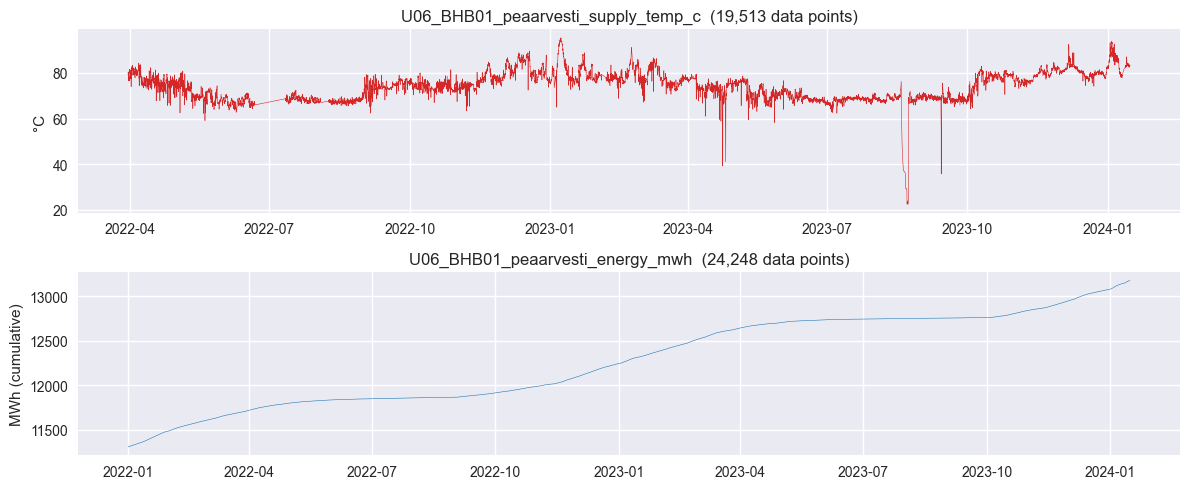

In [15]:
# 2.4c Quick visual: time-series snippet for U06 supply temperature to prove data is intact

if "U06" in building_dfs:
    u06 = building_dfs["U06"]

    # Find a supply-temperature column
    temp_cols = [c for c in u06.columns if "supply_temp" in c]
    energy_cols = [c for c in u06.columns if "energy_mwh" in c and "peaarvesti" in c]

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

    if temp_cols:
        col = temp_cols[0]
        data = u06[col].dropna()
        axes[0].plot(data.index, data.values, lw=0.4, color="tab:red")
        axes[0].set_ylabel("°C")
        axes[0].set_title(f"{col}  ({len(data):,} data points)")

    if energy_cols:
        col = energy_cols[0]
        data = u06[col].dropna()
        axes[1].plot(data.index, data.values, lw=0.4, color="tab:blue")
        axes[1].set_ylabel("MWh (cumulative)")
        axes[1].set_title(f"{col}  ({len(data):,} data points)")

    plt.tight_layout()
    plt.show()

## 3. Hourly normalization and delta computation

The raw campus time series are recorded at **irregular timestamps** (e.g. 10/20/50/60-minute steps) and different sensors rarely align perfectly.
For modelling and for joining with weather, we normalize everything to a **common hourly grid**.

### Core rule for cumulative meters

For cumulative meters (e.g. district-heating energy `MWh` readings):

- First compute **deltas on the raw cumulative readings** (`diff()` on the original irregular timestamps).
- Then resample those deltas to hourly using **sum**.

This preserves energy conservation over time. Resampling the cumulative series first and then differencing can introduce bias.

### What we do in this section

For each building:

- **Energy (`*_energy_mwh`)**: convert to `*_energy_delta_mwh` (negative deltas are flagged as invalid / resets and set to `NaN`)
- **Temperatures (`*_supply_temp_c`, `*_return_temp_c`)**: hourly **mean**
- **Other instantaneous variables** (if present): hourly **mean**
- Create **heating-group aggregates** (hourly) for modelling targets:
  - `space_heating`, `vent_heating`, `outdoor_heating`, `dhw`, `waste_heat`, `total`
  - plus `weather_driven = space_heating + vent_heating + outdoor_heating` (excludes DHW)

Note: because timestamps are naive (no timezone), DST duplicate wall-clock times may exist in raw data; duplicates are collapsed by keeping the last value.

In [16]:
# 3.1 Helpers: hourly resampling + delta computation

from dataclasses import dataclass


CUMULATIVE_VARS = {"energy_mwh", "flow_volume_m3"}
INSTANT_VARS = {"supply_temp_c", "return_temp_c", "flow_rate_m3h", "power_kw"}


@dataclass
class SeriesQA:
    label: str
    building: str
    heating_group: str | None
    var: str | None
    raw_points: int
    dup_timestamps: int
    negative_deltas: int


def _rename_delta(label: str, var: str) -> str:
    if var == "energy_mwh":
        return label.replace("_energy_mwh", "_energy_delta_mwh")
    if var == "flow_volume_m3":
        return label.replace("_flow_volume_m3", "_flow_volume_delta_m3")
    return f"{label}__delta"


def series_to_hourly(
    s: pd.Series,
    var: str,
    freq: str = "1H",
) -> tuple[pd.Series, int, int]:
    """Convert one raw series to hourly.

    Returns: (hourly_series, dup_timestamps_count, negative_delta_count)

    Notes:
    - Duplicate timestamps are collapsed by keeping the last value.
    - For cumulative variables, we compute diff() first, then resample sum().
    - Negative deltas are treated as invalid (meter resets / bad data) and set to NaN.
    """
    s = s.dropna().sort_index()
    if s.empty:
        return s, 0, 0

    # collapse duplicates (logging artifacts, DST wall-clock duplicates, etc.)
    dup_timestamps = int(len(s) - s.index.nunique())
    s = s.groupby(level=0).last()

    if var in CUMULATIVE_VARS:
        d = s.diff()
        negative = int((d < 0).sum())
        d = d.where(d >= 0)
        hourly = d.resample(freq).sum(min_count=1)
        return hourly, dup_timestamps, negative

    # instantaneous variables: hourly mean
    hourly = s.resample(freq).mean()
    return hourly, dup_timestamps, 0


def building_raw_to_hourly(
    building: str,
    df_raw: pd.DataFrame,
    label_meta: pd.DataFrame,
    freq: str = "1H",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Convert one building raw DataFrame to hourly + return QA table."""
    hourly_parts: list[pd.Series] = []
    qa_rows: list[dict] = []

    for label in df_raw.columns:
        if label not in label_meta.index:
            # should not happen, but skip silently
            continue

        meta = label_meta.loc[label]
        var = meta.get("mõõdetud_en")
        group = meta.get("heating_group")

        if not isinstance(var, str) or not var:
            continue

        s = df_raw[label]
        hourly, dupes, negatives = series_to_hourly(s, var=var, freq=freq)
        if hourly is None or hourly.empty:
            continue

        if var in CUMULATIVE_VARS:
            hourly.name = _rename_delta(label, var)
        else:
            hourly.name = label

        hourly_parts.append(hourly)

        qa_rows.append(
            {
                "label": label,
                "hourly_label": hourly.name,
                "building": building,
                "heating_group": group,
                "var": var,
                "raw_points": int(s.notna().sum()),
                "dup_timestamps": int(dupes),
                "negative_deltas": int(negatives),
            }
        )

    df_hourly = pd.concat(hourly_parts, axis=1).sort_index() if hourly_parts else pd.DataFrame()
    qa_df = pd.DataFrame(qa_rows).sort_values(["var", "heating_group", "label"]).reset_index(drop=True)
    return df_hourly, qa_df


def add_heating_group_aggregates(
    building: str,
    df_hourly: pd.DataFrame,
    label_meta: pd.DataFrame,
) -> pd.DataFrame:
    """Add hourly aggregate delta columns per heating group."""
    out = df_hourly.copy()

    # Map original energy labels -> heating_group, then find corresponding *_energy_delta_mwh columns
    energy_meta = label_meta[(label_meta["mõõdetud_en"] == "energy_mwh")].copy()
    if energy_meta.empty:
        return out

    energy_meta["delta_col"] = energy_meta.index.map(lambda x: x.replace("_energy_mwh", "_energy_delta_mwh"))

    group_cols: dict[str, list[str]] = {}
    for _, r in energy_meta.iterrows():
        grp = r.get("heating_group")
        col = r.get("delta_col")
        if not isinstance(grp, str) or not isinstance(col, str):
            continue
        if col in out.columns:
            group_cols.setdefault(grp, []).append(col)

    # Per-group aggregates
    for grp, cols in group_cols.items():
        out[f"{building}__{grp}__energy_delta_mwh"] = out[cols].sum(axis=1, min_count=1)

    # Weather-driven aggregate (exclude DHW, waste heat, total)
    wd_groups = [g for g in ["space_heating", "vent_heating", "outdoor_heating"] if g in group_cols]
    wd_cols = [f"{building}__{g}__energy_delta_mwh" for g in wd_groups if f"{building}__{g}__energy_delta_mwh" in out.columns]
    if wd_cols:
        out[f"{building}__weather_driven__energy_delta_mwh"] = out[wd_cols].sum(axis=1, min_count=1)

    return out

In [17]:
# 3.2 Build hourly DataFrames for all buildings

# Build a label -> metadata lookup (label is unique)
label_meta = (
    manifest_df[["label", "Hoone", "heating_group", "mõõdetud_en", "unit", "type", "level"]]
    .drop_duplicates(subset=["label"])
    .set_index("label")
)

building_hourly_dfs: dict[str, pd.DataFrame] = {}
building_qa: dict[str, pd.DataFrame] = {}

for building, df_raw in sorted(building_dfs.items()):
    meta_b = label_meta[label_meta["Hoone"] == building]
    df_hourly, qa_df = building_raw_to_hourly(building, df_raw, meta_b, freq="1h")
    df_hourly = add_heating_group_aggregates(building, df_hourly, meta_b)

    building_hourly_dfs[building] = df_hourly
    building_qa[building] = qa_df

    n_hours = df_hourly.shape[0]
    n_cols = df_hourly.shape[1]
    n_energy_delta_cols = sum(c.endswith("_energy_delta_mwh") for c in df_hourly.columns)
    print(f"{building}: hourly rows={n_hours:,}, cols={n_cols:,} (energy delta cols={n_energy_delta_cols})")

print(f"\nTotal buildings with hourly data: {len(building_hourly_dfs)}")

GEO: hourly rows=22,886, cols=19 (energy delta cols=9)
ICO: hourly rows=22,956, cols=16 (energy delta cols=8)
LIB: hourly rows=22,955, cols=13 (energy delta cols=7)
SOC: hourly rows=22,955, cols=16 (energy delta cols=8)
STU: hourly rows=17,608, cols=2 (energy delta cols=2)
U01: hourly rows=22,955, cols=17 (energy delta cols=9)
U01U02: hourly rows=17,746, cols=2 (energy delta cols=2)
U02: hourly rows=22,927, cols=12 (energy delta cols=6)
U02B: hourly rows=26,275, cols=11 (energy delta cols=7)
U03: hourly rows=26,275, cols=22 (energy delta cols=12)
U03B: hourly rows=26,275, cols=15 (energy delta cols=9)
U04: hourly rows=26,275, cols=15 (energy delta cols=13)
U04B: hourly rows=26,275, cols=9 (energy delta cols=9)
U05: hourly rows=26,275, cols=12 (energy delta cols=12)
U05B: hourly rows=26,275, cols=9 (energy delta cols=9)
U06: hourly rows=26,275, cols=25 (energy delta cols=13)
U06A: hourly rows=26,275, cols=7 (energy delta cols=7)

Total buildings with hourly data: 17


U06 — QA summary (showing only energy_mwh sources):


,label,hourly_label,heating_group,raw_points,dup_timestamps,negative_deltas
0,U06_BHB05_vesi_energy_mwh,U06_BHB05_vesi_energy_delta_mwh,dhw,29447,0,1
1,U06_BHB06_väliküte_energy_mwh,U06_BHB06_väliküte_energy_delta_mwh,outdoor_heating,35284,0,0
2,U06_BHB03_radiaatorid_energy_mwh,U06_BHB03_radiaatorid_energy_delta_mwh,space_heating,35284,0,0
3,U06_BHB01_peaarvesti_energy_mwh,U06_BHB01_peaarvesti_energy_delta_mwh,total,24248,0,1
4,U06_BHB04_ventilatsioon_energy_mwh,U06_BHB04_ventilatsioon_energy_delta_mwh,vent_heating,35284,0,1
5,U06_BHB02_jääksoojus_energy_mwh,U06_BHB02_jääksoojus_energy_delta_mwh,waste_heat,35284,0,1


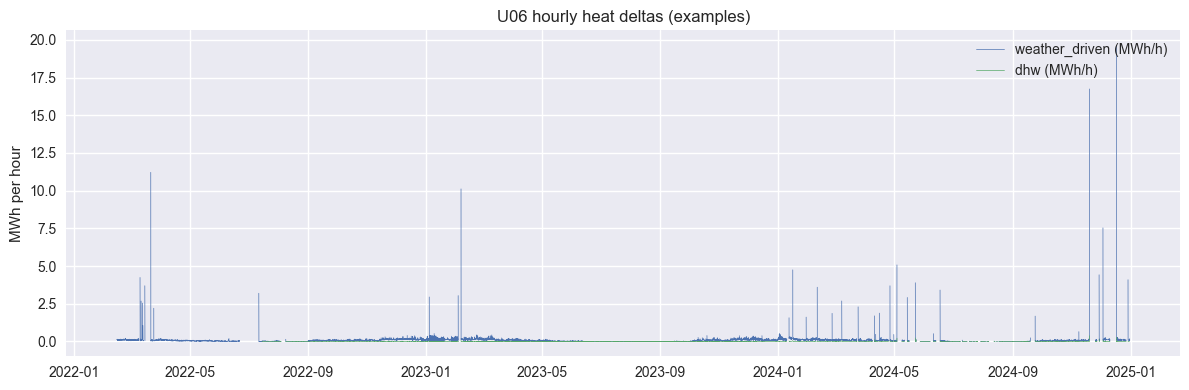

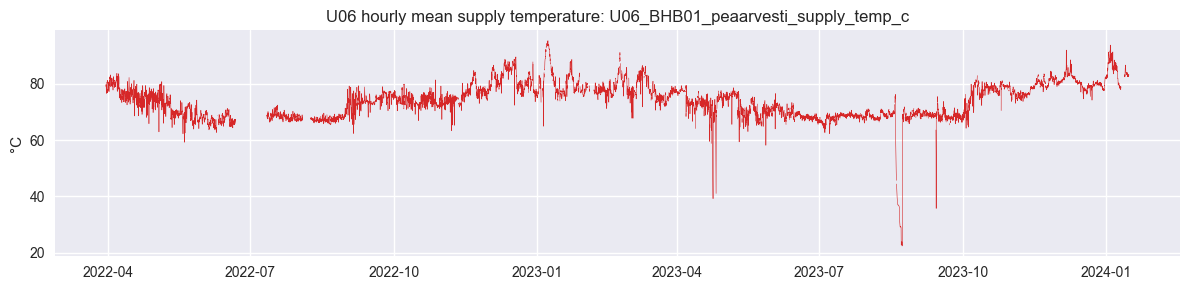

U06 hourly DataFrame preview:


,U06_BHB01_peaarvesti_energy_delta_mwh,U06_BHB01_peaarvesti_supply_temp_c,U06_BHB01_peaarvesti_return_temp_c,U06_BHB02_jääksoojus_energy_delta_mwh,U06_BHB02_jääksoojus_supply_temp_c,U06_BHB02_jääksoojus_return_temp_c,U06_BHB03_radiaatorid_energy_delta_mwh,U06_BHB03_radiaatorid_supply_temp_c,U06_BHB03_radiaatorid_return_temp_c,U06_BHB04_ventilatsioon_energy_delta_mwh,...,U06_BHB06_väliküte_energy_delta_mwh,U06_BHB06_väliküte_supply_temp_c,U06_BHB06_väliküte_return_temp_c,U06__total__energy_delta_mwh,U06__waste_heat__energy_delta_mwh,U06__space_heating__energy_delta_mwh,U06__vent_heating__energy_delta_mwh,U06__dhw__energy_delta_mwh,U06__outdoor_heating__energy_delta_mwh,U06__weather_driven__energy_delta_mwh
Time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.03,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,0.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.21,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 02:00:00,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.23,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 03:00:00,0.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.22,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 04:00:00,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.19,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 05:00:00,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.17,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 06:00:00,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.19,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 07:00:00,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.13,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 08:00:00,0.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.24,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# 3.3 Sanity checks (U06): QA table + example plots

if "U06" in building_hourly_dfs:
    u06_h = building_hourly_dfs["U06"]
    u06_qa = building_qa["U06"]

    print("U06 — QA summary (showing only energy_mwh sources):")
    display(
        u06_qa[u06_qa["var"] == "energy_mwh"][
            ["label", "hourly_label", "heating_group", "raw_points", "dup_timestamps", "negative_deltas"]
        ]
    )

    # Plot: weather-driven hourly heat vs DHW (if available)
    wd_col = "U06__weather_driven__energy_delta_mwh"
    dhw_col = "U06__dhw__energy_delta_mwh"

    fig, ax = plt.subplots(figsize=(12, 4))
    if wd_col in u06_h.columns:
        ax.plot(u06_h[wd_col].index, u06_h[wd_col].values, lw=0.5, label="weather_driven (MWh/h)")
    if dhw_col in u06_h.columns:
        ax.plot(u06_h[dhw_col].index, u06_h[dhw_col].values, lw=0.5, label="dhw (MWh/h)")

    ax.set_title("U06 hourly heat deltas (examples)")
    ax.set_ylabel("MWh per hour")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # Plot: supply temperature (main meter) hourly mean (first available)
    temp_cols = [c for c in u06_h.columns if c.endswith("_supply_temp_c")]
    if temp_cols:
        col = temp_cols[0]
        fig, ax = plt.subplots(figsize=(12, 3))
        ax.plot(u06_h[col].index, u06_h[col].values, lw=0.4, color="tab:red")
        ax.set_title(f"U06 hourly mean supply temperature: {col}")
        ax.set_ylabel("°C")
        plt.tight_layout()
        plt.show()

    print("U06 hourly DataFrame preview:")
    display(u06_h.head(24))

In [19]:
# 3.4 Quick completeness snapshot: percent non-null per aggregate target (all buildings)

agg_cols = [c for df in building_hourly_dfs.values() for c in df.columns if "__energy_delta_mwh" in c and c.count("__") >= 2]
agg_cols = sorted(set(agg_cols))

rows = []
for building, df in sorted(building_hourly_dfs.items()):
    for col in [
        f"{building}__total__energy_delta_mwh",
        f"{building}__weather_driven__energy_delta_mwh",
        f"{building}__dhw__energy_delta_mwh",
    ]:
        if col in df.columns:
            rows.append(
                {
                    "building": building,
                    "target": col.split("__", 1)[1],
                    "hours": int(df.shape[0]),
                    "non_null_hours": int(df[col].notna().sum()),
                    "non_null_pct": float(df[col].notna().mean() * 100.0),
                }
            )

completeness_targets = pd.DataFrame(rows).sort_values(["building", "target"]).reset_index(drop=True)
print("Hourly aggregate target completeness (% non-null):")
display(completeness_targets)

Hourly aggregate target completeness (% non-null):


,building,target,hours,non_null_hours,non_null_pct
0,GEO,dhw__energy_delta_mwh,22886,21509,93.983221
1,GEO,total__energy_delta_mwh,22886,4826,21.087128
2,GEO,weather_driven__energy_delta_mwh,22886,21509,93.983221
3,ICO,dhw__energy_delta_mwh,22956,22089,96.223210
4,ICO,weather_driven__energy_delta_mwh,22956,22089,96.223210
5,LIB,dhw__energy_delta_mwh,22955,15655,68.198650
6,LIB,weather_driven__energy_delta_mwh,22955,15655,68.198650
7,SOC,dhw__energy_delta_mwh,22955,15655,68.198650
8,SOC,weather_driven__energy_delta_mwh,22955,15655,68.198650
9,STU,total__energy_delta_mwh,17608,13972,79.350295


## 4. Weather data loading (Copernicus + Keskkonnaportaal)

We use two weather inputs:

- **Primary (already merged, hourly)**: `combined_weather_2022_2025.csv` with Copernicus ERA5 + Tallinn–Harku station variables.
- **Reference / extended variables (raw KKP export)**: the Keskkonnaportaal station export (`tallinn-harku_f_kliima_tund.csv`) contains a wider set of variables (pressure, precipitation, etc.).

In this section we:

- load the combined weather dataset and restrict it to **2022–2024**;
- load and reshape the raw KKP export for selected variables;
- produce a few plots and basic consistency checks.

In [20]:
# 4.1 Load combined weather (Copernicus + KKP) and restrict to 2022–2024

weather_combined = pd.read_csv(COMBINED_WEATHER_FILE, parse_dates=["datetime"])

# Defensive: drop bad timestamps and collapse duplicate hours (otherwise .asfreq() will error)
weather_combined = weather_combined.dropna(subset=["datetime"]).sort_values("datetime")

n_raw = len(weather_combined)
weather_combined = weather_combined.groupby("datetime", as_index=False).last()
n_dupes = int(n_raw - len(weather_combined))

weather_combined = weather_combined.set_index("datetime").sort_index()
print(f"Combined weather: raw rows={n_raw:,}, duplicate datetimes collapsed={n_dupes:,}")

# Restrict to the building-data window
weather_2022_2024 = weather_combined.loc["2022-01-01":"2024-12-31 23:59:59"].copy()

# Ensure an explicit hourly grid (inserts NaNs for missing hours)
weather_2022_2024 = weather_2022_2024.asfreq("1h")

print("\nCombined weather columns:")
print(list(weather_2022_2024.columns))
print()
print("Weather date range:")
print(weather_2022_2024.index.min(), "→", weather_2022_2024.index.max())
print("Total hourly rows:", len(weather_2022_2024))
print()

missing_pct = (weather_2022_2024.isna().mean() * 100).sort_values(ascending=False)
print("Missing % by column (2022–2024):")
display(missing_pct.to_frame("missing_pct"))

print("\nSummary stats (2022–2024):")
display(weather_2022_2024.describe(include="all"))

Combined weather: raw rows=36,216, duplicate datetimes collapsed=1,128

Combined weather columns:
['COP_temp_c', 'COP_wind_speed_ms', 'COP_ssrd_W_per_m2', 'KKP_temp_c', 'KKP_wind_speed_ms', 'KKP_sunshine_duration_min']

Weather date range:
2022-01-01 00:00:00 → 2024-12-31 23:00:00
Total hourly rows: 26304

Missing % by column (2022–2024):


,missing_pct
COP_ssrd_W_per_m2,2.687804
KKP_temp_c,0.155870
KKP_wind_speed_ms,0.155870
KKP_sunshine_duration_min,0.155870
COP_temp_c,0.000000
COP_wind_speed_ms,0.000000



Summary stats (2022–2024):


,COP_temp_c,COP_wind_speed_ms,COP_ssrd_W_per_m2,KKP_temp_c,KKP_wind_speed_ms,KKP_sunshine_duration_min
count,26304.000000,26304.000000,25597.000000,26263.000000,26263.000000,26263.000000
mean,7.339547,3.438326,118.156820,7.394985,2.987347,14.104748
std,8.934735,1.585467,188.739243,8.829776,1.540299,23.390106
min,-19.666473,0.060748,0.000000,-19.800000,0.100000,0.000000
25%,0.348969,2.264019,0.000000,0.500000,1.800000,0.000000
50%,6.862457,3.224489,4.490556,6.800000,2.800000,0.000000
75%,14.928436,4.414193,169.091660,14.600000,3.900000,24.000000
max,30.039703,11.333722,812.773600,32.000000,10.500000,60.000000


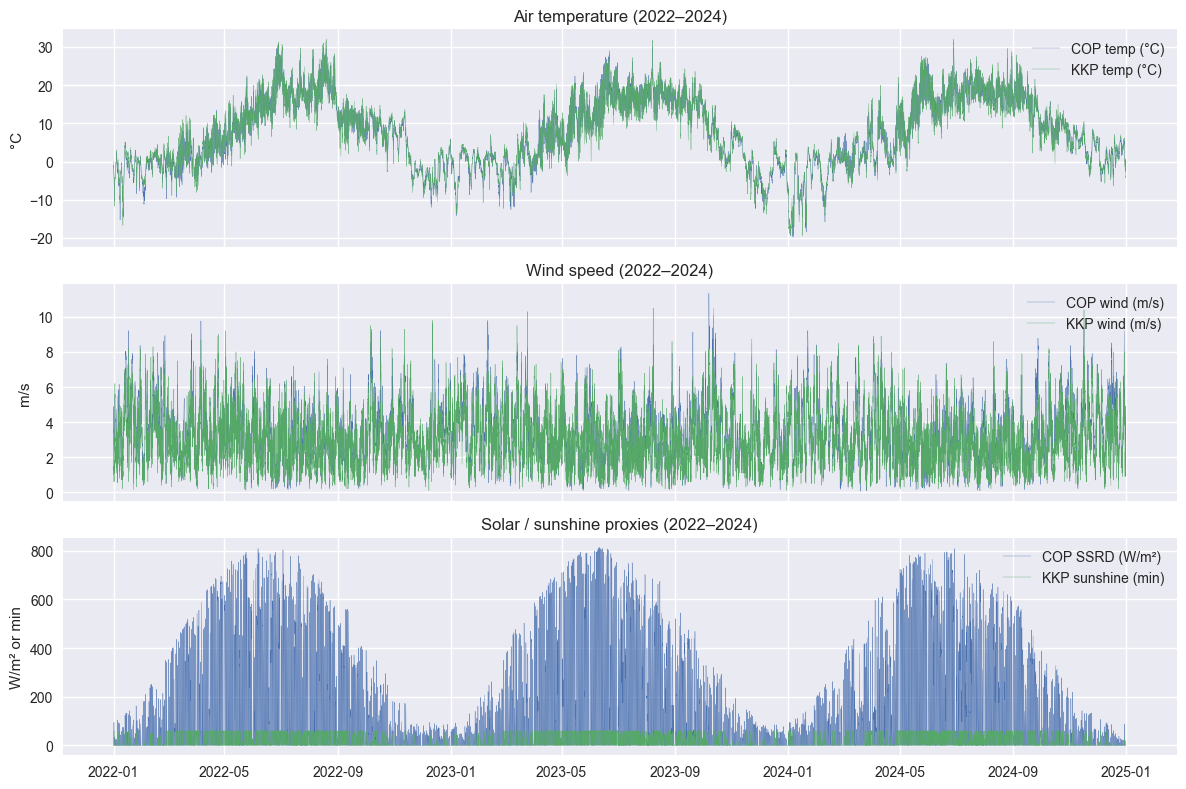

In [21]:
# 4.2 Quick overview plots (combined weather)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

if "COP_temp_c" in weather_2022_2024.columns:
    axes[0].plot(weather_2022_2024.index, weather_2022_2024["COP_temp_c"], lw=0.25, label="COP temp (°C)")
if "KKP_temp_c" in weather_2022_2024.columns:
    axes[0].plot(weather_2022_2024.index, weather_2022_2024["KKP_temp_c"], lw=0.25, label="KKP temp (°C)")
axes[0].set_ylabel("°C")
axes[0].set_title("Air temperature (2022–2024)")
axes[0].legend(loc="upper right")

if "COP_wind_speed_ms" in weather_2022_2024.columns:
    axes[1].plot(weather_2022_2024.index, weather_2022_2024["COP_wind_speed_ms"], lw=0.25, label="COP wind (m/s)")
if "KKP_wind_speed_ms" in weather_2022_2024.columns:
    axes[1].plot(weather_2022_2024.index, weather_2022_2024["KKP_wind_speed_ms"], lw=0.25, label="KKP wind (m/s)")
axes[1].set_ylabel("m/s")
axes[1].set_title("Wind speed (2022–2024)")
axes[1].legend(loc="upper right")

if "COP_ssrd_W_per_m2" in weather_2022_2024.columns:
    axes[2].plot(weather_2022_2024.index, weather_2022_2024["COP_ssrd_W_per_m2"], lw=0.25, label="COP SSRD (W/m²)")
if "KKP_sunshine_duration_min" in weather_2022_2024.columns:
    axes[2].plot(weather_2022_2024.index, weather_2022_2024["KKP_sunshine_duration_min"], lw=0.25, label="KKP sunshine (min)")
axes[2].set_ylabel("W/m² or min")
axes[2].set_title("Solar / sunshine proxies (2022–2024)")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [22]:
# 4.3 Load Keskkonnaportaal raw export (Tallinn–Harku) for extended variables

KKP_RAW_FILE = ENVIRONMENT_PORTAL_DATA_DIR / "tallinn-harku_f_kliima_tund.csv"

kkp_raw = pd.read_csv(
    KKP_RAW_FILE,
    sep=";",
    decimal=",",
    quotechar='"',
)

# Build a UTC-naive timestamp from the year/month/day/hour columns (KKP export states UTC time)
kkp_raw["datetime"] = pd.to_datetime(
    dict(
        year=kkp_raw["aasta - Year of measurement, UTC time"],
        month=kkp_raw["kuu - Month of measurement, UTC time"],
        day=kkp_raw["paev - Day of measurement, UTC time"],
        hour=kkp_raw["tund - Hour of measurement, UTC time"],
    ),
    errors="coerce",
)

# Keep one station only (file should already be Tallinn–Harku, but stay explicit)
kkp_raw = kkp_raw[kkp_raw["jaam_kood - Station code, local"] == "AJHARK01"].copy()

# Select a small set of useful hourly elements
KKP_ELEMENTS = {
    "PA0": "pressure_hpa",
    "PR1H": "precip_mm",
    "SDUR1H": "sunshine_min",
    "WS10M": "wind_ms",
    "TAN1H": "temp_min_c",
    "TAX1H": "temp_max_c",
}

kkp_sel = kkp_raw[kkp_raw["element_kood - Element code, local"].isin(KKP_ELEMENTS)].copy()

# Ensure numeric values
kkp_sel["vaartus - The measured value"] = pd.to_numeric(
    kkp_sel["vaartus - The measured value"], errors="coerce"
)

kkp_wide = (
    kkp_sel[["datetime", "element_kood - Element code, local", "vaartus - The measured value"]]
    .dropna(subset=["datetime"])
    .sort_values("datetime")
    .groupby(["datetime", "element_kood - Element code, local"], as_index=False)
    .last()  # collapse any duplicates by keeping last
    .pivot(index="datetime", columns="element_kood - Element code, local", values="vaartus - The measured value")
    .rename(columns=KKP_ELEMENTS)
    .sort_index()
)

# Restrict to 2022–2024 and make hourly grid
# Pandas >= 3.0 uses lowercase offset aliases ("1h" instead of "1H")
kkp_wide_2022_2024 = kkp_wide.loc["2022-01-01":"2024-12-31 23:59:59"].asfreq("1h")

print("KKP raw (wide) columns:")
print(list(kkp_wide_2022_2024.columns))
print("KKP raw date range:")
print(kkp_wide_2022_2024.index.min(), "→", kkp_wide_2022_2024.index.max())
print("Total hourly rows:", len(kkp_wide_2022_2024))

kkp_missing_pct = (kkp_wide_2022_2024.isna().mean() * 100).sort_values(ascending=False)
print("\nKKP raw missing % by column (2022–2024):")
display(kkp_missing_pct.to_frame("missing_pct"))

display(kkp_wide_2022_2024.head())

KKP raw (wide) columns:
['pressure_hpa', 'precip_mm', 'sunshine_min', 'temp_min_c', 'temp_max_c', 'wind_ms']
KKP raw date range:
2022-01-01 00:00:00 → 2024-12-31 23:00:00
Total hourly rows: 26304

KKP raw missing % by column (2022–2024):


,missing_pct
"element_kood - Element code, local",
wind_ms,0.155870
precip_mm,0.019009
pressure_hpa,0.000000
sunshine_min,0.000000
temp_min_c,0.000000
temp_max_c,0.000000


"element_kood - Element code, local",pressure_hpa,precip_mm,sunshine_min,temp_min_c,temp_max_c,wind_ms
datetime,,,,,,
2022-01-01 00:00:00,1001.6,0.3,0.0,-0.8,0.0,1.4
2022-01-01 01:00:00,1002.0,0.4,0.0,-0.1,0.1,1.0
2022-01-01 02:00:00,1002.4,0.5,0.0,-0.2,-0.1,1.5
2022-01-01 03:00:00,1003.0,0.3,0.0,-0.3,-0.1,1.9
2022-01-01 04:00:00,1004.1,0.2,0.0,-0.4,-0.2,1.3


KKP_wind_speed_ms vs raw wind_ms: n=26,263, corr=1.0000, mean_abs_diff=0.0000
KKP_sunshine_duration_min vs raw sunshine_min: n=26,263, corr=1.0000, mean_abs_diff=0.0000


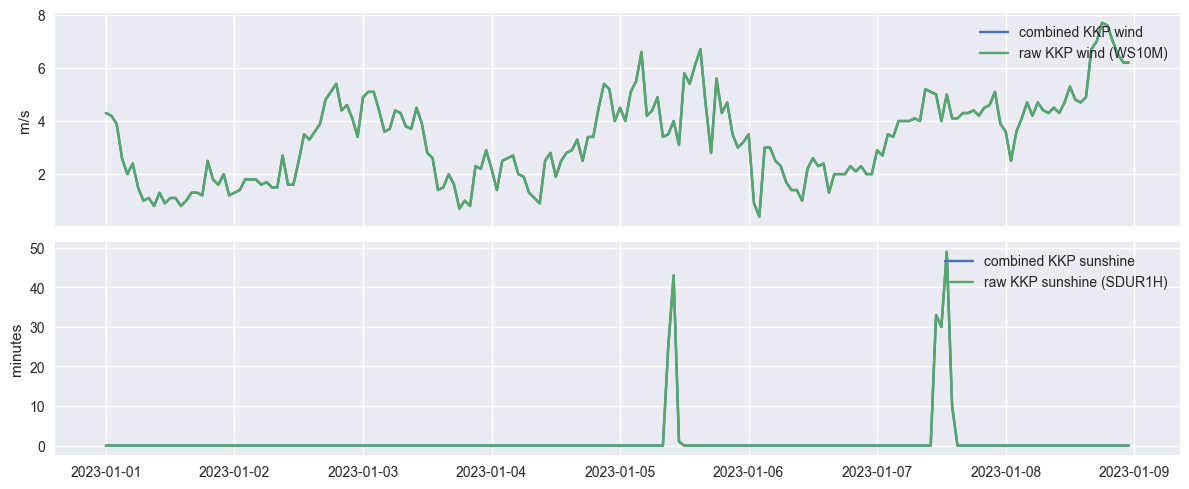

In [23]:
# 4.4 Consistency check: combined KKP vs raw KKP (wind + sunshine)

# Join on datetime index
chk = weather_2022_2024.join(
    kkp_wide_2022_2024[["wind_ms", "sunshine_min", "precip_mm", "pressure_hpa", "temp_min_c", "temp_max_c"]],
    how="left",
    rsuffix="_raw",
)

# Compare where both are present
for combined_col, raw_col in [
    ("KKP_wind_speed_ms", "wind_ms"),
    ("KKP_sunshine_duration_min", "sunshine_min"),
]:
    if combined_col in chk.columns and raw_col in chk.columns:
        both = chk[[combined_col, raw_col]].dropna()
        if len(both) > 0:
            corr = both[combined_col].corr(both[raw_col])
            mad = (both[combined_col] - both[raw_col]).abs().mean()
            print(f"{combined_col} vs raw {raw_col}: n={len(both):,}, corr={corr:.4f}, mean_abs_diff={mad:.4f}")

# Plot one week to visually confirm alignment
week = chk.loc["2023-01-01":"2023-01-08"].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

if "KKP_wind_speed_ms" in week.columns and "wind_ms" in week.columns:
    axes[0].plot(week.index, week["KKP_wind_speed_ms"], label="combined KKP wind")
    axes[0].plot(week.index, week["wind_ms"], label="raw KKP wind (WS10M)")
    axes[0].set_ylabel("m/s")
    axes[0].legend(loc="upper right")

if "KKP_sunshine_duration_min" in week.columns and "sunshine_min" in week.columns:
    axes[1].plot(week.index, week["KKP_sunshine_duration_min"], label="combined KKP sunshine")
    axes[1].plot(week.index, week["sunshine_min"], label="raw KKP sunshine (SDUR1H)")
    axes[1].set_ylabel("minutes")
    axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. Building metadata (EHR / Ehitisregister)

We use the Estonian Building Registry (EHR / Ehitisregister) exports prepared in `ehr-data-exploration.ipynb`.

In this section we:

- load EHR-derived campus building metadata (geometry, areas, volumes, first-use year, materials, HVAC indicators);
- expand compound campus codes like `U06 (+U06A)` into separate campus codes (`U06`, `U06A`) so we can join metadata to the campus heat datasets;
- produce a compact summary table and a few thesis-ready plots (e.g., heated area / gross volume by building).

In [24]:
# 5.1 Load EHR exports (created in ehr-data-exploration.ipynb)

EHR_DIR = DATA_DIR / "ehr-building-data"
EHR_BUILDING_SUMMARY_FILE = EHR_DIR / "ehr_building_summary.csv"
EHR_TECHNICAL_INDICATORS_FILE = EHR_DIR / "ehr_technical_indicators.csv"
EHR_ENERGY_CERTIFICATES_FILE = EHR_DIR / "ehr_energy_certificates.csv"

# Main summary table
EHR_summary = pd.read_csv(EHR_BUILDING_SUMMARY_FILE)

# Optional side tables (may have fewer rows)
EHR_tech = pd.read_csv(EHR_TECHNICAL_INDICATORS_FILE)
EHR_certs = pd.read_csv(EHR_ENERGY_CERTIFICATES_FILE)

print("EHR summary rows:", len(EHR_summary))
print("EHR tech rows:", len(EHR_tech))
print("EHR cert rows:", len(EHR_certs))

print("\nEHR summary columns (first 30):")
print(list(EHR_summary.columns[:30]))

display(EHR_summary.head())

EHR summary rows: 16
EHR tech rows: 16
EHR cert rows: 3

EHR summary columns (first 30):
['campus_code', 'ehr_code', 'name', 'address', 'building_type', 'kaos_code', 'status', 'first_use_year', 'height_m', 'width_m', 'length_m', 'gross_volume_m3', 'footprint_area_m2', 'heated_area_m2', 'net_closed_area_m2', 'max_floors', 'min_floors', 'elevators', 'rooms_count', 'non_residential_count', 'ownership_type', 'energy_class', 'certificate_date', 'issued_date', 'valid_until', 'document_type', 'document_nr', 'source', 'has_certificate', 'heating_supply_type']


,campus_code,ehr_code,name,address,building_type,kaos_code,status,first_use_year,height_m,width_m,...,volume_per_heated_area,compactness_ratio,height_per_floor_m,plan_aspect_ratio,usage_non_res_share_of_heated,building_age_years,footprint_discrepancy_pct,orientation_sin2,orientation_cos2,heated_area_missing_or_zero
0,U01,101026153,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,1968,NaN,NaN,...,5.33,0.252,NaN,NaN,0.983,58,1.703,-0.4226,0.9063,False
1,U02 (+U02B),101026150,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1967,17.2,37.2,...,1.00,0.080,4.30,2.995,0.223,59,0.019,-0.4195,0.9078,False
2,U03 (+U03B),101026151,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1966,17.3,11.4,...,5.16,0.478,4.32,8.807,1.209,60,0.110,-0.4226,0.9063,False
3,U04,101026152,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1965,18.7,12.0,...,4.24,0.300,4.68,6.942,1.000,61,0.008,-0.4195,0.9078,False
4,U04B,101026655,õppehoone n 4B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,1986,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40,0.166,-0.4035,0.9150,True


In [25]:
# 5.2 Expand compound campus codes and join EHR metadata to campus codes

import re


def expand_campus_code(code: str) -> list[str]:
    """Expand EHR campus_code like 'U06 (+U06A)' into ['U06', 'U06A'].

    Keeps simple codes as-is.
    """
    if not isinstance(code, str) or not code.strip():
        return []

    code = code.strip()

    # Find all patterns like U06, U06A, U02B, GEO, ICO, etc.
    tokens = re.findall(r"[A-Z]{2,3}\\d*[A-Z]?", code)
    if tokens:
        # Preserve first-seen order
        seen = {}
        for t in tokens:
            if t not in seen:
                seen[t] = True
        return list(seen.keys())

    return [code]


ehr_expanded = EHR_summary.copy()
ehr_expanded["campus_code_list"] = ehr_expanded["campus_code"].apply(expand_campus_code)
ehr_expanded = ehr_expanded.explode("campus_code_list").rename(columns={"campus_code_list": "campus_code_expanded"})

# Keep one row per expanded campus code (summary is already aggregated)
ehr_expanded = ehr_expanded.dropna(subset=["campus_code_expanded"]).drop_duplicates(subset=["campus_code_expanded"])

print("Expanded EHR campus codes:")
print(sorted(ehr_expanded["campus_code_expanded"].unique()))

# Join with the campus building code table (loaded in Section 1)
# building_codes_df is expected to have 'campus_code'
if "campus_code" in building_codes_df.columns:
    ehr_joined = building_codes_df.merge(
        ehr_expanded,
        left_on="campus_code",
        right_on="campus_code_expanded",
        how="left",
        suffixes=("", "_ehr"),
    )
else:
    ehr_joined = ehr_expanded.copy()

print("\nEHR join preview (campus_code, ehr_code, name):")
display(ehr_joined[[c for c in ["campus_code", "ehr_code", "name", "address", "first_use_year", "heated_area_m2", "gross_volume_m3"] if c in ehr_joined.columns]].head(20))

Expanded EHR campus codes:
['GEO', 'ICO', 'ICT', 'LIB', 'NRG', 'SOC', 'STU', 'TIM', 'U01', 'U02 (+U02B)', 'U03 (+U03B)', 'U04', 'U04B', 'U05', 'U05B', 'U06 (+U06A)']

EHR join preview (campus_code, ehr_code, name):


,campus_code,ehr_code,name,address,first_use_year,heated_area_m2,gross_volume_m3
0,U01,101026153,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",1968,4088.7,21780.0
1,U02 (+U02B),101026150,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",1967,24136.0,24136.0
2,U03 (+U03B),101026151,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",1966,5908.0,30456.0
3,U04,101026152,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",1965,5777.1,24521.0
4,U04B,101026655,õppehoone n 4B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",1986,NaN,6360.0
5,U05,101026146,TTÜ teadus-õppehoone V korpus galeriidega,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",1964,5550.0,29705.0
6,U05B,101026656,õppehoone nr 5B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",2000,NaN,11539.0
7,U06 (+U06A),101026149,õppehoone nr 6,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",1986,12841.2,61946.0
8,GEO,120296180,TTÜ HOONETEKOMPLEKSI III JA IV KORPUSE VAHEHOO...,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",2006,898.2,3875.0
9,STU,120599499,külmaseade,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",2011,NaN,39.0


EHR building metadata (joined to campus codes):


,campus_code,ehr_code,name,address,building_type,kaos_code,status,first_use_year,height_m,width_m,...,compactness_ratio,height_per_floor_m,plan_aspect_ratio,usage_non_res_share_of_heated,building_age_years,footprint_discrepancy_pct,orientation_sin2,orientation_cos2,heated_area_missing_or_zero,campus_code_expanded
1,U02 (+U02B),101026150,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1967,17.2,37.2,...,0.080,4.30,2.995,0.223,59,0.019,-0.4195,0.9078,False,U02 (+U02B)
7,U06 (+U06A),101026149,õppehoone nr 6,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Püstitamisel,1986,18.4,61.4,...,0.307,3.68,2.057,1.000,40,0.128,-0.4226,0.9063,False,U06 (+U06A)
13,ICT,120308870,TEHNOPOLIS-3 hoone Akadeemia tee 15a,"Harju maakond, Tallinn, Mustamäe linnaosa, Aka...",Teadus- ja metoodikaasutuse hoone,12635,Olemas,2008,31.8,45.5,...,0.133,3.98,1.197,1.063,18,0.069,0.0000,1.0000,False,ICT
11,LIB,120551286,raamatukogu hoone,"Harju maakond, Tallinn, Mustamäe linnaosa, Aka...",Raamatukogu,12623,Olemas,2009,23.0,33.4,...,0.228,3.29,1.719,1.039,17,0.095,-0.4226,0.9063,False,LIB
12,SOC,120546679,TTÜ MH ÕPPEHOONE,"Harju maakond, Tallinn, Mustamäe linnaosa, Aka...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,2009,20.3,59.5,...,0.321,4.06,1.000,1.000,17,0.005,0.3971,-0.9178,False,SOC
10,NRG,120224494,TTÜ Energeetikateaduskonna hoone Ehitajate tee 5,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,2004,24.0,39.0,...,0.235,4.00,1.256,1.000,22,0.067,-0.4163,0.9092,False,NRG
2,U03 (+U03B),101026151,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1966,17.3,11.4,...,0.478,4.32,8.807,1.209,60,0.110,-0.4226,0.9063,False,U03 (+U03B)
3,U04,101026152,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1965,18.7,12.0,...,0.300,4.68,6.942,1.000,61,0.008,-0.4195,0.9078,False,U04
5,U05,101026146,TTÜ teadus-õppehoone V korpus galeriidega,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1964,18.2,95.3,...,0.378,3.64,1.998,1.000,62,0.177,-0.4258,0.9048,False,U05
0,U01,101026153,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,1968,NaN,NaN,...,0.252,NaN,NaN,0.983,58,1.703,-0.4226,0.9063,False,U01


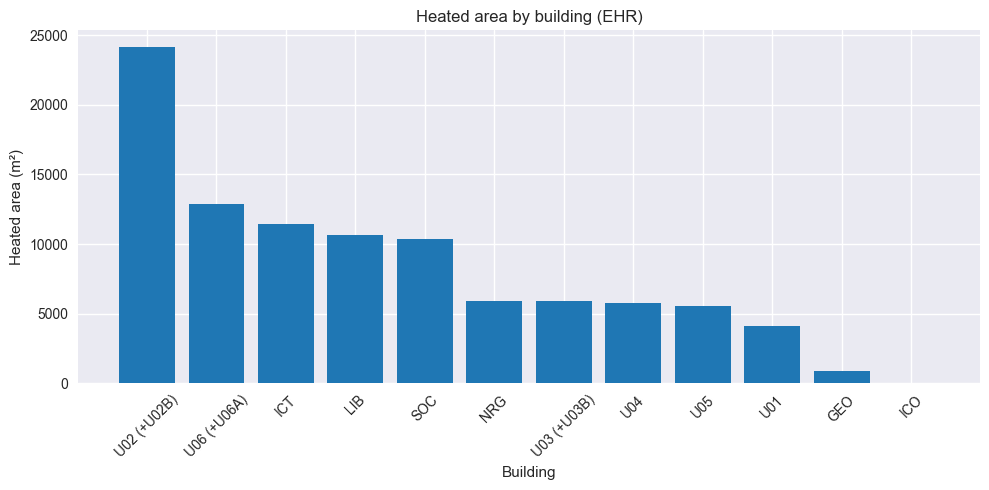

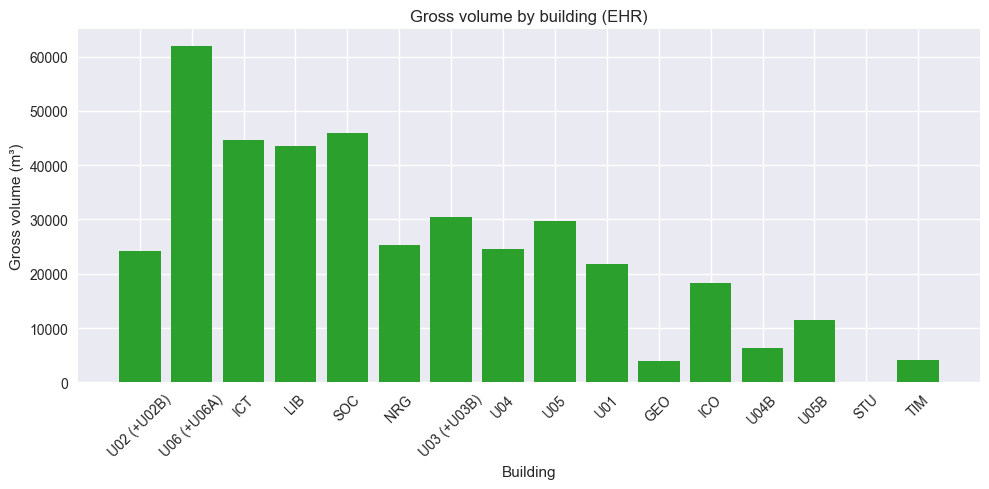

In [26]:
# 5.3 Thesis-ready summary table + size plots

# At this stage we keep **all** available EHR metadata columns
summary_tbl = ehr_joined.copy()

# Numeric conversions (robust in case of strings) for a few key size-related fields
for c in ["heated_area_m2", "gross_volume_m3", "footprint_area_m2", "max_floors", "first_use_year"]:
    if c in summary_tbl.columns:
        summary_tbl[c] = pd.to_numeric(summary_tbl[c], errors="coerce")

summary_tbl = summary_tbl.sort_values("heated_area_m2", ascending=False, na_position="last")

print("EHR building metadata (joined to campus codes):")
display(summary_tbl)

# Plot: heated area
plot_df = summary_tbl.dropna(subset=["heated_area_m2"]).copy()
if len(plot_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["campus_code"].astype(str), plot_df["heated_area_m2"].astype(float), color="tab:blue")
    ax.set_title("Heated area by building (EHR)")
    ax.set_ylabel("Heated area (m²)")
    ax.set_xlabel("Building")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

# Plot: gross volume
plot_df2 = summary_tbl.dropna(subset=["gross_volume_m3"]).copy()
if len(plot_df2) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df2["campus_code"].astype(str), plot_df2["gross_volume_m3"].astype(float), color="tab:green")
    ax.set_title("Gross volume by building (EHR)")
    ax.set_ylabel("Gross volume (m³)")
    ax.set_xlabel("Building")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## 6. Data cleaning (duplicates, relevance, structure, outliers, missing data)

In this section we apply the cleaning structure from the *Energy Data Science – Cleaning* lecture to the campus + weather data.

We work on the **hourly, labelled DataFrames** from Sections 3–5:

- `building_hourly_dfs[building]` — one hourly DataFrame per campus building
- `weather_2022_2024` and `kkp_wide_2022_2024` — hourly weather
- `EHR_summary` / `ehr_joined` — static building metadata

Subsections:

1. **Remove duplicates** (6.1): ensure unique hourly timestamps per building and for weather.
2. **Remove irrelevant observations** (6.2): restrict to 2022–2024, drop all-NaN or unused columns, optionally skip NRG.
3. **Fix structural errors + types** (6.3 & 6.5): enforce datetime index, numeric dtypes for measurements, consistent column naming.
4. **Handle outliers** (6.4): flag negative or extreme hourly energy deltas and physically impossible temperatures.
5. **Handle missing data** (6.6): compute missingness profiles and (conservatively) interpolate short gaps for predictors only.

In [27]:
# 6.1 Remove duplicate timestamps (buildings + weather)

# Buildings
building_clean_dfs: dict[str, pd.DataFrame] = {}

for building, df in building_hourly_dfs.items():
    # Ensure datetime index and sort
    df_c = df.copy()
    if not isinstance(df_c.index, pd.DatetimeIndex):
        df_c.index = pd.to_datetime(df_c.index, errors="coerce")
    df_c = df_c.sort_index()

    # Count duplicates and drop them (keep last)
    dup_count = int(df_c.index.duplicated().sum())
    if dup_count > 0:
        print(f"{building}: found {dup_count} duplicate hourly timestamps → dropping (keep last)")
        df_c = df_c[~df_c.index.duplicated(keep="last")]

    # Ensure a continuous hourly grid (missing hours remain as NaN)
    df_c = df_c.asfreq("1h")

    building_clean_dfs[building] = df_c

# Weather (combined + KKP wide)

weather_clean = weather_2022_2024.copy()
if not isinstance(weather_clean.index, pd.DatetimeIndex):
    weather_clean.index = pd.to_datetime(weather_clean.index, errors="coerce")
weather_clean = weather_clean.sort_index()

weather_dup = int(weather_clean.index.duplicated().sum())
if weather_dup > 0:
    print(f"Weather (combined): found {weather_dup} duplicate hourly timestamps → dropping (keep last)")
    weather_clean = weather_clean[~weather_clean.index.duplicated(keep="last")]

# Ensure continuous hourly grid for weather as well
weather_clean = weather_clean.asfreq("1h")

kkp_clean = kkp_wide_2022_2024.copy()
if not isinstance(kkp_clean.index, pd.DatetimeIndex):
    kkp_clean.index = pd.to_datetime(kkp_clean.index, errors="coerce")
kkp_clean = kkp_clean.sort_index()

kkp_dup = int(kkp_clean.index.duplicated().sum())
if kkp_dup > 0:
    print(f"KKP raw: found {kkp_dup} duplicate hourly timestamps → dropping (keep last)")
    kkp_clean = kkp_clean[~kkp_clean.index.duplicated(keep="last")]

# Continuous hourly grid for raw KKP as well
kkp_clean = kkp_clean.asfreq("1h")

In [28]:
# 6.2 Remove irrelevant observations (time window, empty columns, optional exclusions)

START_DATE = "2022-01-01"
END_DATE = "2024-12-31 23:59:59"

# Optionally skip NRG in this thesis (different structure, electricity, etc.)
EXCLUDED_BUILDINGS = {"NRG"}

building_clean_dfs_window: dict[str, pd.DataFrame] = {}

for building, df in building_clean_dfs.items():
    if building in EXCLUDED_BUILDINGS:
        print(f"Skipping building {building} (excluded from thesis scope)")
        continue

    df_w = df.loc[START_DATE:END_DATE].copy()

    # Drop columns that are entirely NaN in the window
    non_empty_cols = df_w.columns[df_w.notna().any()].tolist()
    dropped = set(df_w.columns) - set(non_empty_cols)
    if dropped:
        print(f"{building}: dropped {len(dropped)} all-NaN columns in 2022–2024 window")
        df_w = df_w[non_empty_cols]

    building_clean_dfs_window[building] = df_w

# Apply the same time-window restriction to weather
weather_clean_window = weather_clean.loc[START_DATE:END_DATE].copy()
kkp_clean_window = kkp_clean.loc[START_DATE:END_DATE].copy()

print("\nBuildings kept after exclusions:", sorted(building_clean_dfs_window.keys()))


Buildings kept after exclusions: ['GEO', 'ICO', 'LIB', 'SOC', 'STU', 'U01', 'U01U02', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']


In [29]:
# 6.3 / 6.5 Structural checks: datetime index + numeric dtypes

# Enforce datetime index and consistent dtypes for building data
for building, df in building_clean_dfs_window.items():
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")
        df = df.sort_index()

    # Convert all non-object columns to numeric where possible
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col], errors="ignore")

    building_clean_dfs_window[building] = df

# Weather: ensure floats for numeric predictors
for col in weather_clean_window.columns:
    if weather_clean_window[col].dtype == "object":
        weather_clean_window[col] = pd.to_numeric(weather_clean_window[col], errors="ignore")

for col in kkp_clean_window.columns:
    if kkp_clean_window[col].dtype == "object":
        kkp_clean_window[col] = pd.to_numeric(kkp_clean_window[col], errors="ignore")

In [ ]:
# Section 6 — Cleaning diagnostics configuration (representative buildings & windows)

# Buildings we will always show in detailed cleaning diagnostics
REP_BUILDINGS: list[str] = ["GEO", "ICO", "U06"]

# Energy groups we report on (if present as aggregated columns)
KEY_ENERGY_GROUPS: list[str] = [
    "space_heating",
    "weather_driven",
    "total",
]

# Representative time windows (local time)
WINTER_WEEK_START = pd.Timestamp("2023-01-15 00:00:00")
SUMMER_WEEK_START = pd.Timestamp("2023-07-15 00:00:00")
SPIKE_WINDOW_DAYS = 7


def energy_group_col(building: str, group: str) -> str:
    """Return the canonical aggregated energy-delta column for a building+group.

    Example: energy_group_col("GEO", "space_heating") →
             "GEO__space_heating__energy_delta_mwh".
    """
    return f"{building}__{group}__energy_delta_mwh"


def available_energy_group_cols(building: str, df: pd.DataFrame) -> list[str]:
    cols: list[str] = []
    for g in KEY_ENERGY_GROUPS:
        c = energy_group_col(building, g)
        if c in df.columns:
            cols.append(c)
    return cols


def pick_primary_energy_col(building: str, df: pd.DataFrame) -> str | None:
    """Choose one "primary" energy column for detailed plots.

    Preference order: space_heating → weather_driven → total →
    first available *_energy_delta_mwh.
    """
    for g in KEY_ENERGY_GROUPS:
        c = energy_group_col(building, g)
        if c in df.columns:
            return c
    # Fallback: any energy-delta column
    energy_cols = [c for c in df.columns if c.endswith("_energy_delta_mwh")]
    return energy_cols[0] if energy_cols else None


print("Cleaning diagnostics configured for buildings:", REP_BUILDINGS)

In [ ]:
# 6.5 Missingness mechanism diagnostics (buildings + weather)

from collections import Counter


def compute_missing_run_lengths(mask: pd.Series) -> Counter:
    """Return a Counter of consecutive NaN run lengths given a boolean mask."""
    counts: Counter = Counter()
    run = 0
    for is_missing in mask.astype(bool).to_numpy():
        if is_missing:
            run += 1
        elif run:
            counts[run] += 1
            run = 0
    if run:
        counts[run] += 1
    return counts


missing_profiles_buildings: dict[str, pd.DataFrame] = {}

for building, df in building_hourly_dfs.items():
    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        df = df.set_index(pd.to_datetime(df.index, errors="coerce")).sort_index()
    
    # Overall missingness profile
    miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_profiles_buildings[building] = miss_pct.to_frame("missing_pct")

    print(f"\n[Missing profile] {building} (top 10 columns):")
    display(missing_profiles_buildings[building].head(10))

    # Time-based missingness for the primary energy column, if available
    primary_col = pick_primary_energy_col(building, df)
    if primary_col is None:
        continue

    # Daily % missing over the whole period
    daily = (
        df[primary_col]
        .isna()
        .groupby(df.index.date)
        .mean()
        .rename("missing_frac")
        .to_frame()
    )

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(pd.to_datetime(daily.index), daily["missing_frac"] * 100.0, label=f"{primary_col}")
    ax.set_title(f"{building}: daily % missing in {primary_col}")
    ax.set_ylabel("% missing")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run-length distribution of missing stretches
    runs = compute_missing_run_lengths(df[primary_col].isna())
    if runs:
        lengths, counts = zip(*sorted(runs.items()))
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.bar(lengths, counts)
        ax.set_title(f"{building}: run-lengths of missing {primary_col} (hours)")
        ax.set_xlabel("Run length [hours]")
        ax.set_ylabel("Count")
        ax.set_xscale("log")
        ax.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()

# Weather missingness vs temperature (MCAR/MAR hints)
if "COP_temp_c" in weather_2022_2024.columns:
    temp_bins = pd.cut(weather_2022_2024["COP_temp_c"], bins=15)
    miss_frac = (
        weather_2022_2024["COP_temp_c"].isna().groupby(temp_bins).mean().rename("missing_frac")
    )
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(miss_frac.index.astype(str), miss_frac.values * 100.0)
    ax.set_title("Weather: % missing COP_temp_c by temperature bin")
    ax.set_ylabel("% missing")
    ax.set_xlabel("COP_temp_c bin")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

In [30]:
# 6.4 Outlier handling: hourly energy deltas + temperatures

import numpy as np

# Robust outlier removal strategy (per building, per energy column)
ENERGY_CLIP_K = 8.0
ENERGY_FALLBACK_Q = 0.999

ROLLING_SPIKE_FILTER_ENABLED = True
ROLLING_WINDOW_HOURS = 24
ROLLING_K = 10.0
ROLLING_MIN_PERIODS = 12


def mad(x: pd.Series) -> float:
    """Median Absolute Deviation (MAD) for a numeric series."""
    med = np.nanmedian(x)
    return float(np.nanmedian(np.abs(x - med)))


def robust_clip_positive(series: pd.Series, k: float = ENERGY_CLIP_K, fallback_q: float = ENERGY_FALLBACK_Q) -> pd.Series:
    """Robust clipping for positive-valued series.

    - Keeps <=0 as-is (negatives handled separately).
    - Computes median + MAD on positive values.
    - Values above median + k * 1.4826 * MAD are set to NaN.
    - If MAD is 0/NaN or too few points, falls back to quantile cap.
    """
    s = series.copy()
    pos = s[s > 0]
    if pos.dropna().shape[0] < 20:
        return s

    med = float(np.nanmedian(pos))
    mad_val = mad(pos)

    if not np.isfinite(mad_val) or mad_val <= 0:
        upper = float(np.nanquantile(pos, fallback_q))
    else:
        robust_sigma = 1.4826 * mad_val
        upper = med + k * robust_sigma

    return s.where((s <= upper) | (s <= 0))


def rolling_spike_filter(series: pd.Series,
                         window: int = ROLLING_WINDOW_HOURS,
                         k: float = ROLLING_K,
                         min_periods: int = ROLLING_MIN_PERIODS) -> pd.Series:
    """Second-stage spike filter using rolling median + rolling MAD.

    Flags isolated spikes relative to local behavior.
    """
    s = series.copy()
    pos = s.where(s > 0)

    roll_med = pos.rolling(window=window, min_periods=min_periods, center=True).median()
    roll_mad = pos.rolling(window=window, min_periods=min_periods, center=True).apply(
        lambda x: np.nanmedian(np.abs(x - np.nanmedian(x))), raw=False
    )

    # Convert MAD to robust sigma
    roll_sigma = 1.4826 * roll_mad

    upper = roll_med + k * roll_sigma
    spike_mask = (pos > upper) & np.isfinite(upper)

    s.loc[spike_mask] = np.nan
    return s


building_clean_dfs_outliers: dict[str, pd.DataFrame] = {}

for building, df in building_clean_dfs_window.items():
    df_o = df.copy()

    # Energy deltas: columns ending with '_energy_delta_mwh'
    energy_cols = [c for c in df_o.columns if c.endswith("_energy_delta_mwh")]

    neg_count = 0
    clipped_count = 0
    rolled_count = 0

    for col in energy_cols:
        # 1) Drop negative deltas (meter resets / bad data)
        neg_mask = df_o[col] < 0
        neg_count += int(neg_mask.sum())
        df_o.loc[neg_mask, col] = np.nan

        # 2) Robust global clip for extreme positives
        before_na = int(df_o[col].isna().sum())
        df_o[col] = robust_clip_positive(df_o[col])
        after_na = int(df_o[col].isna().sum())
        clipped_count += max(0, after_na - before_na)

        # 3) Optional rolling spike filter (local anomalies)
        if ROLLING_SPIKE_FILTER_ENABLED:
            before_na = int(df_o[col].isna().sum())
            df_o[col] = rolling_spike_filter(df_o[col])
            after_na = int(df_o[col].isna().sum())
            rolled_count += max(0, after_na - before_na)

    if neg_count > 0:
        print(f"{building}: set {neg_count} negative hourly energy deltas to NaN")
    if clipped_count > 0:
        print(f"{building}: robust-clipped {clipped_count} extreme hourly energy values")
    if ROLLING_SPIKE_FILTER_ENABLED and rolled_count > 0:
        print(f"{building}: rolling-filtered {rolled_count} local spikes")

    # Temperature sanity: supply/return temps outside [0, 150] °C → NaN
    temp_cols = [c for c in df_o.columns if c.endswith("_supply_temp_c") or c.endswith("_return_temp_c")]
    for col in temp_cols:
        bad = (df_o[col] < 0) | (df_o[col] > 150)
        if bad.any():
            print(f"{building}: {int(bad.sum())} temp values outside [0, 150] °C set to NaN in {col}")
            df_o.loc[bad, col] = np.nan

    building_clean_dfs_outliers[building] = df_o

GEO: robust-clipped 4941 extreme hourly energy values
GEO: rolling-filtered 4031 local spikes
ICO: robust-clipped 3590 extreme hourly energy values
ICO: rolling-filtered 1680 local spikes
LIB: robust-clipped 926 extreme hourly energy values
LIB: rolling-filtered 152 local spikes
SOC: robust-clipped 1122 extreme hourly energy values
SOC: rolling-filtered 118 local spikes
STU: robust-clipped 254 extreme hourly energy values
STU: rolling-filtered 554 local spikes
U01: robust-clipped 1476 extreme hourly energy values
U01: rolling-filtered 1405 local spikes
U01U02: robust-clipped 24 extreme hourly energy values
U01U02: rolling-filtered 1246 local spikes
U02: robust-clipped 2976 extreme hourly energy values
U02: rolling-filtered 716 local spikes
U02B: robust-clipped 2971 extreme hourly energy values
U02B: rolling-filtered 3180 local spikes
U03: robust-clipped 2212 extreme hourly energy values
U03: rolling-filtered 2581 local spikes
U03B: robust-clipped 8719 extreme hourly energy values
U03B:

Outlier removal impact (added NaNs + extreme-value reduction) — key energy cols


,building,col,added_nan_count,added_nan_pct,p999_before,p999_after,max_before,max_after
0,GEO,GEO__vent_heating__energy_delta_mwh,2981,13.025430,0.041492,0.013000,91.907,0.013
1,GEO,GEO__space_heating__energy_delta_mwh,783,3.421306,0.018000,0.017000,134.939,0.021
2,GEO,GEO__weather_driven__energy_delta_mwh,590,2.577995,0.057000,0.052000,226.846,0.055
3,GEO,GEO__total__energy_delta_mwh,426,1.861400,0.050000,0.010000,3.580,0.010
4,GEO,GEO__dhw__energy_delta_mwh,1,0.004369,0.001000,0.001000,0.992,0.005
...,...,...,...,...,...,...,...,...
67,U06,U06__outdoor_heating__energy_delta_mwh,2,0.007612,0.096590,0.095592,1.521,0.122
68,U06A,U06A__total__energy_delta_mwh,1208,4.597526,0.178460,0.170000,5.750,0.260
69,U06A,U06A__vent_heating__energy_delta_mwh,356,1.354900,0.033000,0.026000,1.114,0.026
70,U06A,U06A__space_heating__energy_delta_mwh,94,0.357755,0.320316,0.092550,5.932,0.107


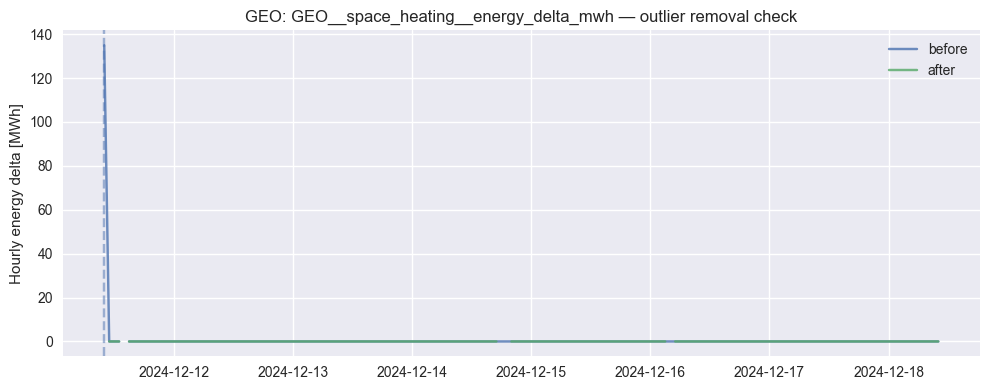


Missing % for GEO (top 10 columns):


,missing_pct
GEO__total__energy_delta_mwh,80.774272
GEO_BHB01_peaarvesti_energy_delta_mwh,80.774272
GEO_BHB01_peaarvesti_flow_rate_m3h,78.912872
GEO_BHB01_peaarvesti_supply_temp_c,78.912872
GEO_BHB01_peaarvesti_return_temp_c,78.912872
GEO_BHB01_peaarvesti_flow_volume_delta_m3,78.912872
GEO__vent_heating__energy_delta_mwh,19.042209
GEO_BHB03_ventilatsioon_energy_delta_mwh,19.042209
GEO_BHB02_küte_energy_delta_mwh,9.438084
GEO__space_heating__energy_delta_mwh,9.438084



Missing % for ICO (top 10 columns):


,missing_pct
ICO_BHB03_vesi_energy_delta_mwh,11.522042
ICO__dhw__energy_delta_mwh,11.522042
ICO_BHB04_küte_energy_delta_mwh,5.750131
ICO_BHB02_ventilatsioon_energy_delta_mwh,4.983447
ICO__vent_heating__energy_delta_mwh,4.983447
ICO__weather_driven__energy_delta_mwh,4.957310
ICO_BHB01_küte_energy_delta_mwh,4.952953
ICO__space_heating__energy_delta_mwh,4.499913
ICO_BHB01_küte_supply_temp_c,3.776790
ICO_BHB04_küte_supply_temp_c,3.776790



Missing % for LIB (top 10 columns):


...


Weather (combined) missing % (top 10):


,missing_pct
COP_ssrd_W_per_m2,2.687804
KKP_temp_c,0.155870
KKP_wind_speed_ms,0.155870
KKP_sunshine_duration_min,0.155870
COP_temp_c,0.000000
COP_wind_speed_ms,0.000000



KKP raw missing % (top 10):


,missing_pct
"element_kood - Element code, local",
wind_ms,0.155870
precip_mm,0.019009
pressure_hpa,0.000000
sunshine_min,0.000000
temp_min_c,0.000000
temp_max_c,0.000000



Section 6 cleaning complete. Use building_clean_final[...] and weather_clean_final / kkp_clean_final for downstream steps.


In [31]:
# 6.6 Missing data: basic profiles and conservative interpolation (predictors only)

# --- Diagnostics: outlier removal impact (before/after) ---

DIAGNOSTIC_BUILDING = "GEO"  # change to inspect another building
DIAGNOSTIC_GROUP_PREF = ["space_heating", "weather_driven", "total"]
DIAGNOSTIC_WINDOW_DAYS = 7


def percentile_summary(s: pd.Series) -> dict:
    s = s.dropna()
    if s.empty:
        return {"p95": np.nan, "p99": np.nan, "p999": np.nan, "max": np.nan}
    return {
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "p999": float(s.quantile(0.999)),
        "max": float(s.max()),
    }


def key_energy_cols(building: str, df: pd.DataFrame) -> list[str]:
    cols: list[str] = []
    for grp in ["space_heating", "weather_driven", "total", "vent_heating", "dhw", "outdoor_heating"]:
        c = f"{building}__{grp}__energy_delta_mwh"
        if c in df.columns:
            cols.append(c)
    return cols


def pick_primary_energy_col(building: str, df: pd.DataFrame) -> str | None:
    for grp in DIAGNOSTIC_GROUP_PREF:
        c = f"{building}__{grp}__energy_delta_mwh"
        if c in df.columns:
            return c
    energy_cols = [c for c in df.columns if c.endswith("_energy_delta_mwh")]
    return energy_cols[0] if energy_cols else None


impact_rows: list[dict] = []

for building, df_after in building_clean_dfs_outliers.items():
    df_before = building_clean_dfs_window.get(building)
    if df_before is None:
        continue

    for col in key_energy_cols(building, df_after):
        before_na = int(df_before[col].isna().sum())
        after_na = int(df_after[col].isna().sum())
        added_na = max(0, after_na - before_na)

        b = percentile_summary(df_before[col])
        a = percentile_summary(df_after[col])

        impact_rows.append({
            "building": building,
            "col": col,
            "added_nan_count": added_na,
            "added_nan_pct": (added_na / max(1, len(df_after))) * 100,
            "p999_before": b["p999"],
            "p999_after": a["p999"],
            "max_before": b["max"],
            "max_after": a["max"],
        })

impact_df = pd.DataFrame(impact_rows)

if not impact_df.empty:
    print("Outlier removal impact (added NaNs + extreme-value reduction) — key energy cols")
    display(
        impact_df.sort_values(["building", "added_nan_count"], ascending=[True, False])
        .groupby("building")
        .head(6)
        .reset_index(drop=True)
    )

# Plot around the largest BEFORE spike (before vs after) for one building
if DIAGNOSTIC_BUILDING in building_clean_dfs_outliers and DIAGNOSTIC_BUILDING in building_clean_dfs_window:
    df_b = building_clean_dfs_window[DIAGNOSTIC_BUILDING]
    df_a = building_clean_dfs_outliers[DIAGNOSTIC_BUILDING]

    primary_col = pick_primary_energy_col(DIAGNOSTIC_BUILDING, df_a)
    if primary_col is not None and not df_b[primary_col].dropna().empty:
        t_max = df_b[primary_col].idxmax()
        w0 = t_max - pd.Timedelta(days=DIAGNOSTIC_WINDOW_DAYS)
        w1 = t_max + pd.Timedelta(days=DIAGNOSTIC_WINDOW_DAYS)

        plt.figure()
        plt.plot(df_b.loc[w0:w1].index, df_b.loc[w0:w1, primary_col], label="before", alpha=0.8)
        plt.plot(df_a.loc[w0:w1].index, df_a.loc[w0:w1, primary_col], label="after", alpha=0.8)
        plt.axvline(t_max, linestyle="--", alpha=0.5)
        plt.title(f"{DIAGNOSTIC_BUILDING}: {primary_col} — outlier removal check")
        plt.ylabel("Hourly energy delta [MWh]")
        plt.legend()
        plt.tight_layout()
        plt.show()

from collections import defaultdict

missing_profiles: dict[str, pd.DataFrame] = {}

for building, df in building_clean_dfs_outliers.items():
    miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_profiles[building] = miss_pct.to_frame("missing_pct")

    print(f"\nMissing % for {building} (top 10 columns):")
    display(missing_profiles[building].head(10))

# Weather missingness
weather_missing = (weather_clean_window.isna().mean() * 100).sort_values(ascending=False)
kkp_missing = (kkp_clean_window.isna().mean() * 100).sort_values(ascending=False)

print("\nWeather (combined) missing % (top 10):")
display(weather_missing.to_frame("missing_pct").head(10))

print("\nKKP raw missing % (top 10):")
display(kkp_missing.to_frame("missing_pct").head(10))

# Conservative interpolation for predictors only

building_clean_final: dict[str, pd.DataFrame] = {}

for building, df in building_clean_dfs_outliers.items():
    df_i = df.copy()

    # Do NOT interpolate target energy deltas; only predictors (temps etc.)
    predictor_cols = [
        c
        for c in df_i.columns
        if not c.endswith("_energy_delta_mwh")
    ]

    # Short gaps: up to 3 hours → time interpolation
    df_i[predictor_cols] = df_i[predictor_cols].interpolate(
        method="time", limit=3, limit_direction="both"
    )

    building_clean_final[building] = df_i

# Weather: allow slightly longer interpolation (up to 6 hours)
weather_clean_final = weather_clean_window.copy().interpolate(
    method="time", limit=6, limit_direction="both"
)
kkp_clean_final = kkp_clean_window.copy().interpolate(
    method="time", limit=6, limit_direction="both"
)

print("\nSection 6 cleaning complete. Use building_clean_final[...] and weather_clean_final / kkp_clean_final for downstream steps.")

## 7. Merge building + weather (+ EHR static metadata)

In this section we create the **model table** for each building by merging:

- the cleaned hourly building data from Section 6 (`building_clean_final[building]`)
- the hourly weather predictors (combined Copernicus+KKP, plus selected KKP-raw variables)
- static EHR metadata (same value repeated for all timestamps; prefixed with `EHR__`)

We use a **left join on the building’s hourly index** so the target timeline is preserved; weather gaps remain `NaN` at this stage.

In [32]:
# 7.1 Build weather feature table (combined + selected raw KKP columns)

# Prefix raw KKP columns to avoid name collisions with the combined file
kkp_raw_prefixed = kkp_clean_final.add_prefix("KKP_raw_")

weather_features = weather_clean_final.join(kkp_raw_prefixed, how="left")

# Optional: add constant baseline (often used as a simple feature)
weather_features["indoor_temp_constant_c"] = 21.0

print("Weather feature columns:")
print(list(weather_features.columns))
print("\nWeather feature table shape:", weather_features.shape)
print("Date range:", weather_features.index.min(), "→", weather_features.index.max())

Weather feature columns:
['COP_temp_c', 'COP_wind_speed_ms', 'COP_ssrd_W_per_m2', 'KKP_temp_c', 'KKP_wind_speed_ms', 'KKP_sunshine_duration_min', 'KKP_raw_pressure_hpa', 'KKP_raw_precip_mm', 'KKP_raw_sunshine_min', 'KKP_raw_temp_min_c', 'KKP_raw_temp_max_c', 'KKP_raw_wind_ms', 'indoor_temp_constant_c']

Weather feature table shape: (26304, 13)
Date range: 2022-01-01 00:00:00 → 2024-12-31 23:00:00


In [33]:
# 7.2 Merge per-building hourly data with weather and EHR static metadata

# Prepare EHR lookup by campus code (expanded)
# ehr_expanded is created in Section 5.2
if "campus_code_expanded" in ehr_expanded.columns:
    ehr_lookup = ehr_expanded.set_index("campus_code_expanded")
else:
    ehr_lookup = pd.DataFrame().set_index(pd.Index([], name="campus_code_expanded"))

building_merged_dfs: dict[str, pd.DataFrame] = {}

for building, df in sorted(building_clean_final.items()):
    df_m = df.join(weather_features, how="left")

    # Attach EHR static columns (prefixed) if available
    if building in ehr_lookup.index:
        ehr_row = ehr_lookup.loc[building]
        # If duplicate index somehow exists, take first row
        if isinstance(ehr_row, pd.DataFrame):
            ehr_row = ehr_row.iloc[0]

        for col, val in ehr_row.items():
            if col in {"campus_code", "campus_code_expanded"}:
                continue
            df_m[f"EHR__{col}"] = val

    building_merged_dfs[building] = df_m

    print(f"{building}: rows={df_m.shape[0]:,}, cols={df_m.shape[1]:,} (weather cols added={weather_features.shape[1]})")

print("\nTotal merged building tables:", len(building_merged_dfs))

GEO: rows=22,886, cols=106 (weather cols added=13)
ICO: rows=22,956, cols=103 (weather cols added=13)
LIB: rows=22,955, cols=100 (weather cols added=13)
SOC: rows=22,955, cols=103 (weather cols added=13)
STU: rows=17,608, cols=89 (weather cols added=13)
U01: rows=22,955, cols=104 (weather cols added=13)
U01U02: rows=17,746, cols=15 (weather cols added=13)
U02: rows=22,927, cols=25 (weather cols added=13)
U02B: rows=26,275, cols=24 (weather cols added=13)
U03: rows=26,275, cols=35 (weather cols added=13)
U03B: rows=26,275, cols=28 (weather cols added=13)
U04: rows=26,275, cols=102 (weather cols added=13)
U04B: rows=26,275, cols=96 (weather cols added=13)
U05: rows=26,275, cols=99 (weather cols added=13)
U05B: rows=26,275, cols=96 (weather cols added=13)
U06: rows=26,275, cols=38 (weather cols added=13)
U06A: rows=26,275, cols=20 (weather cols added=13)

Total merged building tables: 17


In [34]:
# 7.3 Quick sanity check: one building preview (U06 if available)

if "U06" in building_merged_dfs:
    u06_model = building_merged_dfs["U06"]
    print("U06 merged table preview:")
    display(u06_model.head(24))

    # Basic check: correlation between temperature and weather-driven heat (should be negative in heating season)
    if "U06__weather_driven__energy_delta_mwh" in u06_model.columns and "COP_temp_c" in u06_model.columns:
        both = u06_model[["U06__weather_driven__energy_delta_mwh", "COP_temp_c"]].dropna()
        if len(both) > 0:
            print("\nU06 weather-driven heat vs COP temp correlation (all available hours):", both.corr().iloc[0, 1])

U06 merged table preview:


,U06_BHB01_peaarvesti_energy_delta_mwh,U06_BHB01_peaarvesti_supply_temp_c,U06_BHB01_peaarvesti_return_temp_c,U06_BHB02_jääksoojus_energy_delta_mwh,U06_BHB02_jääksoojus_supply_temp_c,U06_BHB02_jääksoojus_return_temp_c,U06_BHB03_radiaatorid_energy_delta_mwh,U06_BHB03_radiaatorid_supply_temp_c,U06_BHB03_radiaatorid_return_temp_c,U06_BHB04_ventilatsioon_energy_delta_mwh,...,KKP_temp_c,KKP_wind_speed_ms,KKP_sunshine_duration_min,KKP_raw_pressure_hpa,KKP_raw_precip_mm,KKP_raw_sunshine_min,KKP_raw_temp_min_c,KKP_raw_temp_max_c,KKP_raw_wind_ms,indoor_temp_constant_c
Time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.4,0.0,1001.6,0.3,0.0,-0.8,0.0,1.4,21.0
2022-01-01 01:00:00,0.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.1,1.0,0.0,1002.0,0.4,0.0,-0.1,0.1,1.0,21.0
2022-01-01 02:00:00,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.1,1.5,0.0,1002.4,0.5,0.0,-0.2,-0.1,1.5,21.0
2022-01-01 03:00:00,0.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.3,1.9,0.0,1003.0,0.3,0.0,-0.3,-0.1,1.9,21.0
2022-01-01 04:00:00,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.4,1.3,0.0,1004.1,0.2,0.0,-0.4,-0.2,1.3,21.0
2022-01-01 05:00:00,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.4,2.9,0.0,1005.3,0.2,0.0,-0.4,-0.2,2.9,21.0
2022-01-01 06:00:00,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.3,4.3,0.0,1006.7,0.0,0.0,-1.3,-0.4,4.3,21.0
2022-01-01 07:00:00,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.8,4.9,0.0,1008.6,0.0,0.0,-2.8,-1.3,4.9,21.0
2022-01-01 08:00:00,0.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.9,3.4,0.0,1010.1,0.0,0.0,-3.2,-2.8,3.4,21.0



U06 weather-driven heat vs COP temp correlation (all available hours): -0.8302153218987713


## 8. Completeness report and data-availability overview

In this section we summarise **how complete the cleaned data is**, across buildings and key variables.

We focus on:

- per-building completeness for **target-like energy deltas** (total + weather-driven + DHW where available);
- a **heatmap** of target completeness by building;
- a **Gantt-style timeline** of data availability per building.

In [35]:
# 8.1 Per-building completeness for key target aggregates

completeness_rows = []

for building, df in sorted(building_clean_final.items()):
    n_hours = len(df)

    # Look for standard aggregate target columns created earlier
    total_col = f"{building}__total__energy_delta_mwh"
    wd_col = f"{building}__weather_driven__energy_delta_mwh"
    dhw_col = f"{building}__dhw__energy_delta_mwh"

    row = {"building": building, "hours": n_hours}

    for label, col in [
        ("total", total_col),
        ("weather_driven", wd_col),
        ("dhw", dhw_col),
    ]:
        if col in df.columns:
            pct = float(df[col].notna().mean() * 100.0)
        else:
            pct = float("nan")
        row[f"{label}_non_null_pct"] = pct

    completeness_rows.append(row)

completeness_targets_clean = pd.DataFrame(completeness_rows).set_index("building").sort_index()

print("Target aggregate completeness (% non-null):")
display(completeness_targets_clean)

Target aggregate completeness (% non-null):


,hours,total_non_null_pct,weather_driven_non_null_pct,dhw_non_null_pct
building,,,,
GEO,22886,19.225728,91.405226,93.978852
ICO,22956,NaN,95.042690,88.477958
LIB,22955,NaN,67.588761,67.593117
SOC,22955,NaN,67.479852,67.863211
STU,17608,77.055884,NaN,NaN
U01,22955,NaN,90.503158,82.295796
U01U02,17746,87.456328,NaN,NaN
U02,22927,NaN,83.421294,80.904610
U02B,26275,57.781161,73.720266,NaN


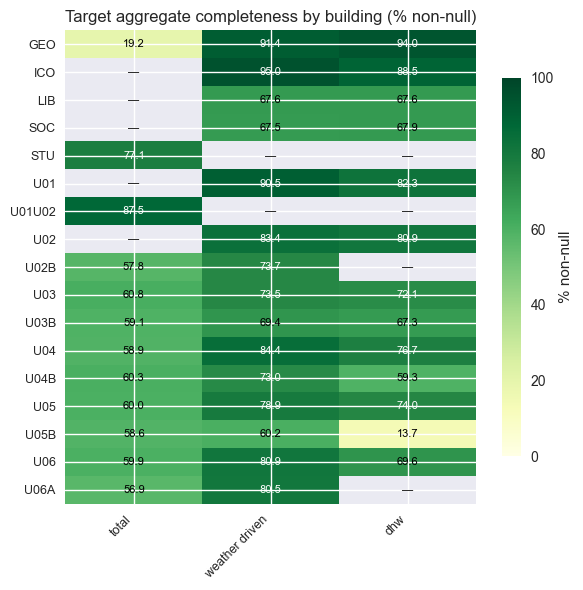

In [36]:
# 8.2 Heatmap: target completeness by building

import numpy as np

if not completeness_targets_clean.empty:
    heatmap_df = completeness_targets_clean[[
        c
        for c in [
            "total_non_null_pct",
            "weather_driven_non_null_pct",
            "dhw_non_null_pct",
        ]
        if c in completeness_targets_clean.columns
    ]].copy()

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlGn", vmin=0, vmax=100)

    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index, fontsize=9)

    col_labels = [
        c.replace("_non_null_pct", "").replace("_", " ")
        for c in heatmap_df.columns
    ]
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(col_labels, fontsize=9, rotation=45, ha="right")

    for i in range(heatmap_df.shape[0]):
        for j in range(heatmap_df.shape[1]):
            val = heatmap_df.iloc[i, j]
            txt = "—" if np.isnan(val) else f"{val:.1f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if not np.isnan(val) and val >= 70 else "black")

    ax.set_title("Target aggregate completeness by building (% non-null)")
    plt.colorbar(im, ax=ax, label="% non-null", shrink=0.8)
    plt.tight_layout()
    plt.show()

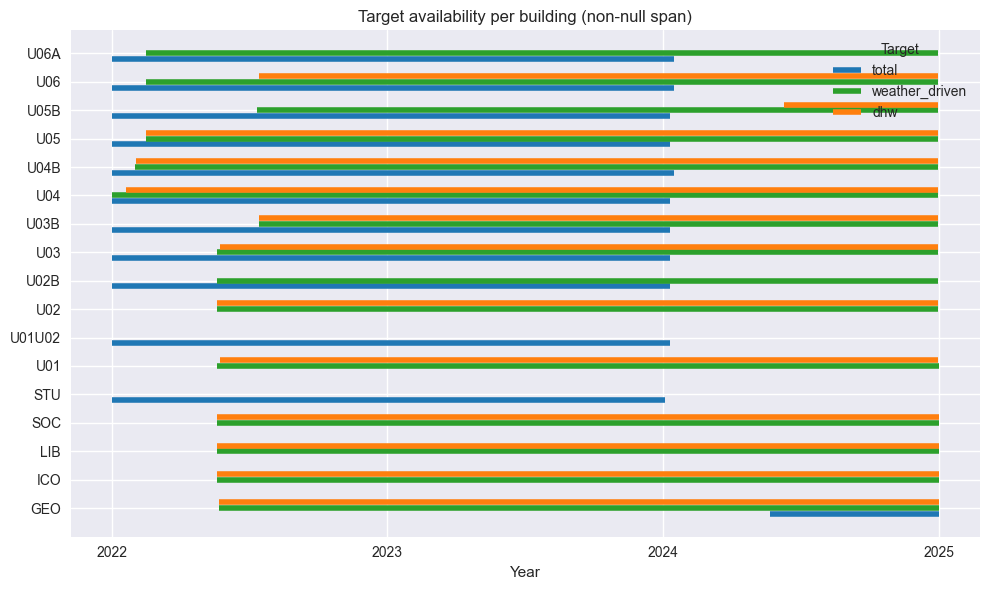

In [37]:
# 8.3 Gantt-style timeline: data availability per building (key targets)

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 6))

yticks = []
ylabels = []

# We visualise three target aggregates per building (where available):
# - total__energy_delta_mwh
# - weather_driven__energy_delta_mwh
# - dhw__energy_delta_mwh

targets = [
    ("total", "total__energy_delta_mwh", "tab:blue"),
    ("weather_driven", "weather_driven__energy_delta_mwh", "tab:green"),
    ("dhw", "dhw__energy_delta_mwh", "tab:orange"),
]

for idx, (building, df) in enumerate(sorted(building_clean_final.items())):
    base_y = idx
    has_any = False

    for t_idx, (label, suffix, color) in enumerate(targets):
        col = f"{building}__{suffix}"
        if col not in df.columns:
            continue

        s = df[col].dropna()
        if s.empty:
            continue

        start = s.index.min()
        end = s.index.max()

        # Small vertical offset per target so they don't overlap
        y = base_y + (t_idx - 1) * 0.2
        ax.hlines(y=y, xmin=start, xmax=end, color=color, linewidth=4, label=label if idx == 0 else "")
        has_any = True

    if has_any:
        yticks.append(base_y)
        ylabels.append(building)

if yticks:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("Year")
    ax.set_title("Target availability per building (non-null span)")

    # One legend entry per target
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, title="Target", loc="upper right")

    plt.tight_layout()
    plt.show()
else:
    print("No buildings with target aggregates found for Gantt-style plot.")

## 9. Exploratory sanity-check plots

These plots are intended to **visually sanity-check** the cleaned, merged data and can be adapted for the final thesis.

We focus on one reference building (U06 if available, otherwise the first building):

- **Energy signature**: hourly heat vs outdoor temperature.
- **Daily pattern**: average hourly profile in winter vs summer.
- **Supply–return temperature difference** for a representative heating circuit.

Reference building for plots: U06


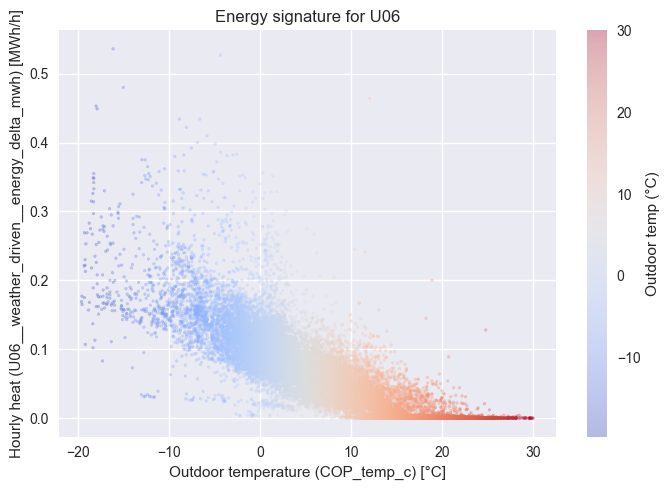

In [38]:
# 9.1 Energy signature: hourly heat vs outdoor temperature (reference building)

# Pick reference building
if "U06" in building_merged_dfs:
    ref_building = "U06"
else:
    ref_building = sorted(building_merged_dfs.keys())[0]

print(f"Reference building for plots: {ref_building}")

ref_df = building_merged_dfs[ref_building]

# Prefer weather-driven heat; fall back to total if needed
heat_cols = [
    f"{ref_building}__weather_driven__energy_delta_mwh",
    f"{ref_building}__total__energy_delta_mwh",
]
heat_col = next((c for c in heat_cols if c in ref_df.columns), None)

# Prefer COP temperature; fall back to KKP
temp_cols = ["COP_temp_c", "KKP_temp_c"]
temp_col = next((c for c in temp_cols if c in ref_df.columns), None)

if heat_col is None or temp_col is None:
    print("Cannot plot energy signature: missing heat or temperature column.")
else:
    data = ref_df[[heat_col, temp_col]].dropna()
    if data.empty:
        print("No overlapping non-null data for energy signature plot.")
    else:
        # Optionally downsample for readability
        if len(data) > 20_000:
            data = data.sample(20_000, random_state=42)

        x = data[temp_col]
        y = data[heat_col]

        fig, ax = plt.subplots(figsize=(7, 5))
        sc = ax.scatter(x, y, s=4, alpha=0.3, c=x, cmap="coolwarm")
        ax.set_xlabel(f"Outdoor temperature ({temp_col}) [°C]")
        ax.set_ylabel(f"Hourly heat ({heat_col}) [MWh/h]")
        ax.set_title(f"Energy signature for {ref_building}")
        plt.colorbar(sc, ax=ax, label="Outdoor temp (°C)")
        plt.tight_layout()
        plt.show()

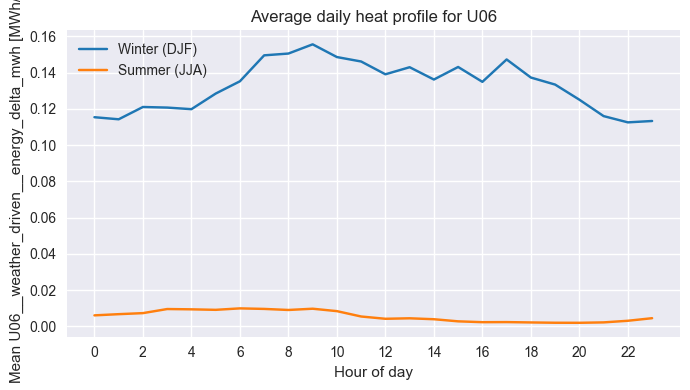

In [39]:
# 9.2 Daily pattern: average hourly heat profile (winter vs summer)

import numpy as np

if heat_col is not None:
    df = ref_df.copy()
    s = df[heat_col].dropna()
    if s.empty:
        print("No data for daily pattern plot.")
    else:
        df = s.to_frame("heat")
        df["month"] = df.index.month
        df["hour"] = df.index.hour

        winter = df[df["month"].isin([12, 1, 2])]
        summer = df[df["month"].isin([6, 7, 8])]

        winter_profile = winter.groupby("hour")["heat"].mean()
        summer_profile = summer.groupby("hour")["heat"].mean()

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(winter_profile.index, winter_profile.values, label="Winter (DJF)", color="tab:blue")
        ax.plot(summer_profile.index, summer_profile.values, label="Summer (JJA)", color="tab:orange")
        ax.set_xlabel("Hour of day")
        ax.set_ylabel(f"Mean {heat_col} [MWh/h]")
        ax.set_title(f"Average daily heat profile for {ref_building}")
        ax.set_xticks(range(0, 24, 2))
        ax.legend()
        plt.tight_layout()
        plt.show()

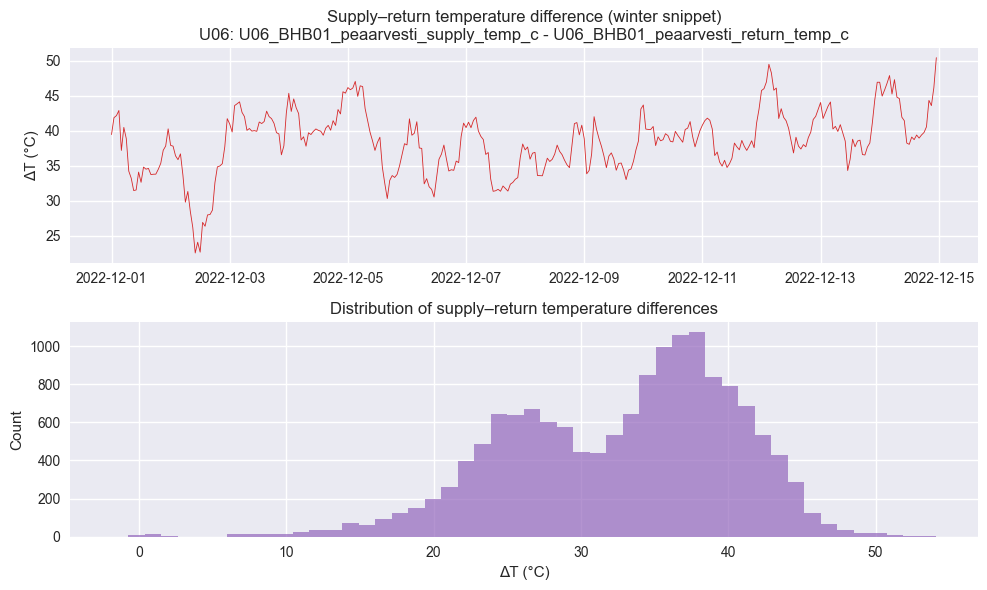

In [40]:
# 9.3 Supply–return temperature difference for a representative circuit

# Heuristic: pick the first pair of *_supply_temp_c / *_return_temp_c in the cleaned building data
ref_clean_df = building_clean_final[ref_building]

supply_cols = [c for c in ref_clean_df.columns if c.endswith("_supply_temp_c")]
return_cols = [c for c in ref_clean_df.columns if c.endswith("_return_temp_c")]

if not supply_cols or not return_cols:
    print("No supply/return temperature columns found for representative delta plot.")
else:
    supply_col = supply_cols[0]
    # Try to find matching return by replacing suffix; fall back to first return col
    candidate = supply_col.replace("_supply_temp_c", "_return_temp_c")
    return_col = candidate if candidate in return_cols else return_cols[0]

    df_tr = ref_clean_df[[supply_col, return_col]].dropna()
    if df_tr.empty:
        print("No overlapping non-null data for supply–return delta plot.")
    else:
        delta = df_tr[supply_col] - df_tr[return_col]

        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

        # Time series snippet (first winter)
        winter_mask = (delta.index.month.isin([12, 1, 2]))
        winter_delta = delta[winter_mask].iloc[:24 * 14]  # first ~2 weeks
        axes[0].plot(winter_delta.index, winter_delta.values, lw=0.6, color="tab:red")
        axes[0].set_ylabel("ΔT (°C)")
        axes[0].set_title(f"Supply–return temperature difference (winter snippet)\n{ref_building}: {supply_col} - {return_col}")

        # Histogram of ΔT
        axes[1].hist(delta.values, bins=50, color="tab:purple", alpha=0.7)
        axes[1].set_xlabel("ΔT (°C)")
        axes[1].set_ylabel("Count")
        axes[1].set_title("Distribution of supply–return temperature differences")

        plt.tight_layout()
        plt.show()

## 10. Export clean, merged datasets

Finally, we export the cleaned and merged per-building tables, along with weather and a compact metadata summary, so that modelling notebooks can load them directly.

In [41]:
# 10.1 Export per-building tables, weather, and metadata

from pathlib import Path

EXPORT_DIR = PROJECT_ROOT / "data" / "clean"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Per-building merged tables
for building, df in sorted(building_merged_dfs.items()):
    csv_path = EXPORT_DIR / f"{building}_hourly_merged.csv"
    df.to_csv(csv_path, index=True)

# Weather features
weather_csv = EXPORT_DIR / "weather_features_hourly.csv"
print(f"\nWriting weather features: {weather_csv.name}")
weather_features.to_csv(weather_csv, index=True)

# Compact building metadata summary (EHR + basic completeness)
meta_rows = []
for building, df in sorted(building_clean_final.items()):
    row = {"building": building, "hours": len(df)}
    total_col = f"{building}__total__energy_delta_mwh"
    wd_col = f"{building}__weather_driven__energy_delta_mwh"
    if total_col in df.columns:
        row["total_non_null_pct"] = float(df[total_col].notna().mean() * 100.0)
    if wd_col in df.columns:
        row["weather_driven_non_null_pct"] = float(df[wd_col].notna().mean() * 100.0)
    meta_rows.append(row)

meta_df = pd.DataFrame(meta_rows).set_index("building").sort_index()
meta_csv = EXPORT_DIR / "building_metadata_summary.csv"
print(f"Writing metadata summary: {meta_csv.name}")
meta_df.to_csv(meta_csv)

print("\nExport completed.")


Writing weather features: weather_features_hourly.csv
Writing metadata summary: building_metadata_summary.csv

Export completed.
